# 목차

1. Library import
2. 데이터 전처리

    - 2.1 원천 데이터 검토 및 EDA
    - 2.2 결측치·이상치 처리
    - 2.3 데이터 병합
    - 2.4 Feature Engineering
    - 2.5 최종 Feature set
3. 모델링



## [1] Library import

In [ ]:
import os
import gc
import re
import json
import time
import math
import random
import warnings
warnings.filterwarnings("ignore")
import shutil
from pathlib import Path
from datetime import datetime, timedelta
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm

from scipy import stats
from scipy.spatial import cKDTree

from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from IPython.display import display
from packaging import version

In [ ]:
# Colab에서 한글 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

# matplotlib font cache 삭제
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

# NanumGothic 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

print("NanumGothic font setting complete.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
NanumGothic font setting complete.


In [ ]:
# ------------------------------
# Label constants
# ------------------------------
TARGET_COL = "LAST_GRADE"

GRADE_ORDER = [
    "등외",
    "3C", "3B", "3A",
    "2C", "2B", "2A",
    "1C", "1B", "1A",
    "1+C", "1+B", "1+A",
    "1++C", "1++B", "1++A",
]
QUALITY_ORDER = [
    "등외",
    "3",
    "2",
    "1",
    "1+",
    "1++",
]
NONOUT_QUALITY_ORDER = [
    "3",
    "2",
    "1",
    "1+",
    "1++",
]
YIELD_ORDER = [
    "C",
    "B",
    "A",
]

grade_to_id = {g: i for i, g in enumerate(GRADE_ORDER)}
id_to_grade = {i: g for i, g in enumerate(GRADE_ORDER)}

quality_to_id = {q: i for i, q in enumerate(QUALITY_ORDER)}
id_to_quality = {i: q for q, i in quality_to_id.items()}

yield_to_id = {y: i for i, y in enumerate(YIELD_ORDER)}
id_to_yield = {i: y for y, i in yield_to_id.items()}

In [ ]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("/content/drive/MyDrive/FINAL")

## [2] 데이터 전처리

### 2.1 원천 데이터 검토 및 EDA

In [ ]:
train = pd.read_csv(f"{DATA_DIR}/hanwoo_train.csv")
test = pd.read_csv(f"{DATA_DIR}/test_hanwoo.csv")
weather = pd.read_csv(f"{DATA_DIR}/hanwoo_weather.csv")
area = pd.read_csv(f"{DATA_DIR}/hanwoo_area.csv")
death = pd.read_csv(f"{DATA_DIR}/hanwoo_death.csv")
lineage = pd.read_csv(f"{DATA_DIR}/hanwoo_lineage_0612.csv")
print("train:", train.shape)
print("test:", test.shape)
print("weather:", weather.shape)
print("area:", area.shape)
print("death:", death.shape)
print("lineage:", lineage.shape)

train: (2408699, 23)
test: (452497, 13)
weather: (973248, 7)
area: (91896, 5)
death: (321389, 4)
lineage: (1840667, 8)


In [ ]:
# 타겟 정의
TARGET = "LAST_GRADE"

print("TARGET:", TARGET)
print("TARGET in train:", TARGET in train.columns)

TARGET: LAST_GRADE
TARGET in train: True


In [ ]:
## 데이터 구조, 결측 확인
datasets = {"train": train}

if "test" in globals():
    datasets["test"] = test
if "area" in globals():
    datasets["area"] = area
if "death" in globals():
    datasets["death"] = death
if "weather" in globals():
    datasets["weather"] = weather
if "lineage" in globals():
    datasets["lineage"] = lineage


overview = []

for name, df in datasets.items():
    overview.append({
        "dataset": name,
        "n_rows": len(df),
        "n_cols": df.shape[1],
        "duplicated_rows": df.duplicated().sum(),
        "memory_MB": df.memory_usage(deep=True).sum() / 1024**2
    })

overview_df = pd.DataFrame(overview)
display(overview_df)


missing_summary = []

for name, df in datasets.items():
    miss = df.isna().mean().sort_values(ascending=False)
    top_miss = miss[miss > 0].head(20)

    for col, rate in top_miss.items():
        missing_summary.append({
            "dataset": name,
            "column": col,
            "missing_rate": rate
        })

missing_summary_df = pd.DataFrame(missing_summary)
display(missing_summary_df)

,dataset,n_rows,n_cols,duplicated_rows,memory_MB
0,train,2408699,23,0,1881.002599
1,test,452497,13,0,282.535774
2,area,91896,5,16,9.202206
3,death,321389,4,8103,46.875047
4,weather,973248,7,0,99.313419
5,lineage,1840667,8,0,1256.182680


,dataset,column,missing_rate
0,test,LAST_GRADE,1.00000
1,lineage,KPN_NO,0.05617


,count,ratio_percent
LAST_GRADE,,
1++B,319588,13.268075
1+B,311222,12.920751
1B,299290,12.425380
1++A,207026,8.594930
2B,195866,8.131610
1A,168174,6.981943
1+A,167246,6.943416
1+C,130094,5.401007
1++C,128997,5.355464


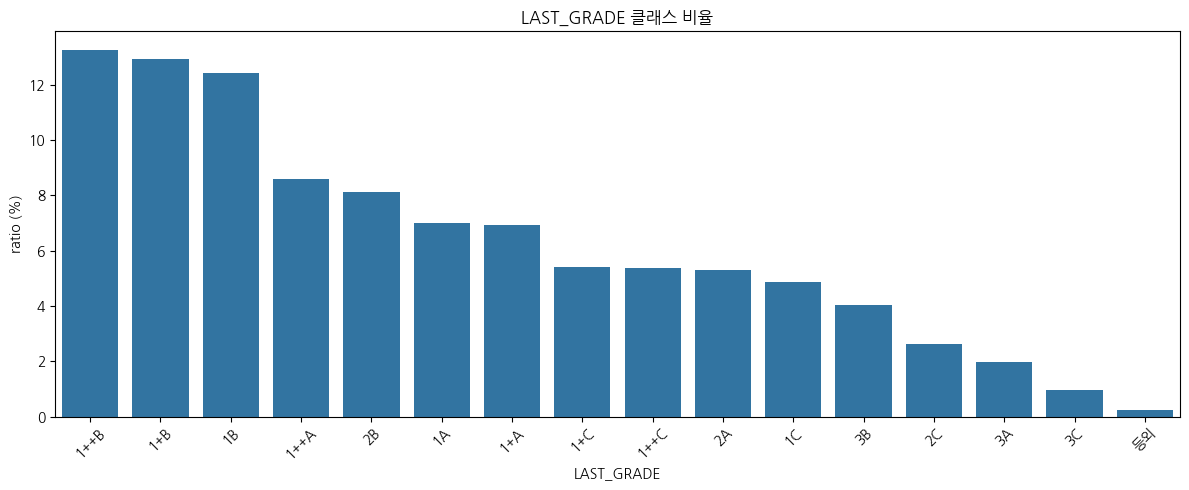

In [ ]:
## 타깃 클래스 불균형
grade_count = train[TARGET].value_counts(dropna=False)
grade_ratio = train[TARGET].value_counts(normalize=True, dropna=False) * 100

target_dist = pd.DataFrame({
    "count": grade_count,
    "ratio_percent": grade_ratio
})

display(target_dist)


plt.figure(figsize=(12, 5))
sns.barplot(x=grade_ratio.index.astype(str), y=grade_ratio.values)
plt.title("LAST_GRADE 클래스 비율")
plt.xlabel("LAST_GRADE")
plt.ylabel("ratio (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

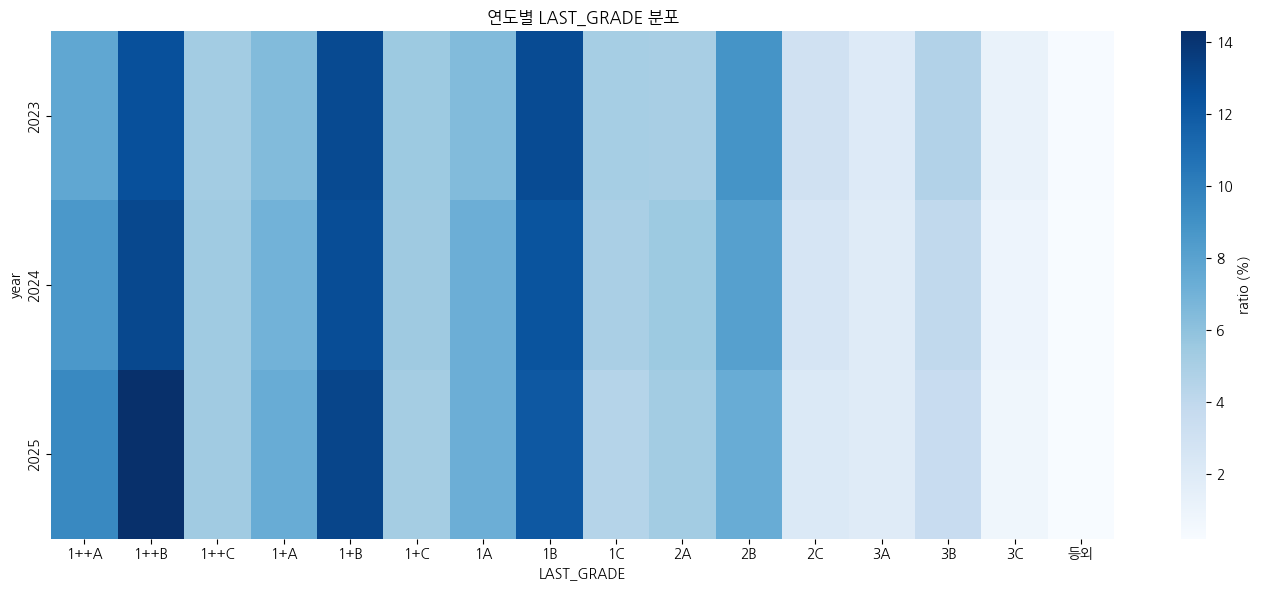

In [ ]:
## 연도별 등급 변화 분포
date_col = "ABATT_DATE" if "ABATT_DATE" in train.columns else "JUDGE_DATE"

train[date_col] = pd.to_datetime(train[date_col], errors="coerce")
train["year"] = train[date_col].dt.year

grade_year = pd.crosstab(
    train["year"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(grade_year, cmap="Blues", cbar_kws={"label": "ratio (%)"})
plt.title("연도별 LAST_GRADE 분포")
plt.xlabel("LAST_GRADE")
plt.ylabel("year")
plt.tight_layout()
plt.show()

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
JUDGE_SEX,,,,,,,,,,,,,,,,
거세,13.125693,19.458471,7.464263,8.553456,15.304405,6.023731,6.567877,10.950416,4.023673,2.980944,3.676751,1.020397,0.245079,0.486967,0.054889,0.062987
수,0.033841,0.084602,0.093063,0.101523,0.473773,0.177665,0.346870,1.573604,1.006768,4.323181,10.575296,3.536379,34.027073,36.006768,4.864636,2.774958
암,3.964956,6.957087,3.213347,5.336363,10.564843,4.805375,7.479730,14.069911,5.761937,7.702395,12.744143,4.261359,3.422643,7.439199,1.898479,0.378231


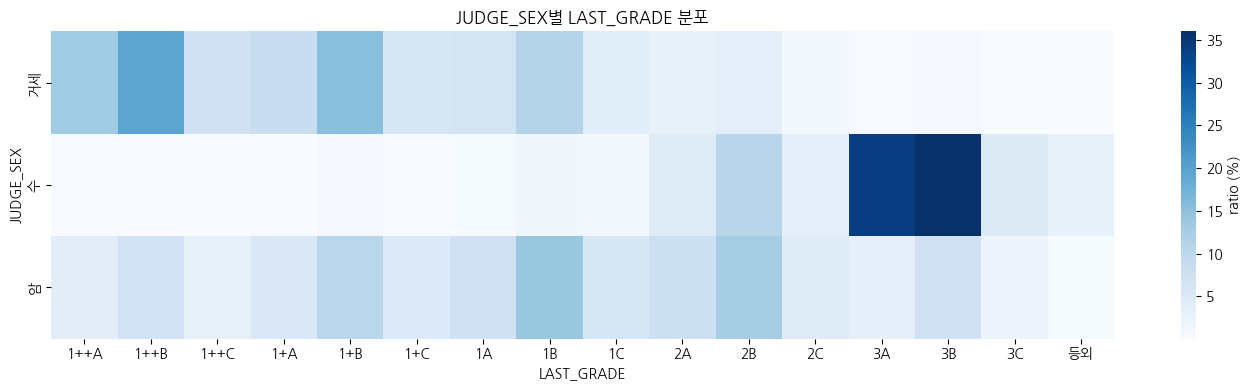

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
age_group,,,,,,,,,,,,,,,,
0-20,1.212871,1.361386,0.371287,1.881188,1.943069,0.544554,3.465347,4.839109,0.556931,6.225248,14.467822,0.841584,4.207921,37.747525,4.876238,15.457921
21-24,5.139129,4.469001,0.878711,7.318156,7.602183,1.402388,10.482404,11.676208,1.744109,11.534194,16.606755,1.642036,4.011894,12.137754,1.735233,1.619846
25-28,9.934195,11.661341,3.364112,9.770171,13.604135,3.898005,9.765597,13.516569,3.696080,6.552438,8.246257,1.719304,1.291275,2.402190,0.322819,0.255510
29-32,12.477383,18.358454,6.949335,8.448719,15.309287,6.065415,6.668165,11.561566,4.373174,3.215916,4.378282,1.295856,0.322602,0.473233,0.064021,0.038594
33-36,11.272156,18.837818,8.453714,7.200894,14.699484,6.866138,5.879189,11.267926,4.844102,3.219868,4.783677,1.509628,0.370609,0.649573,0.094666,0.050556
37-48,5.194441,8.982866,3.912474,6.295973,12.359489,4.925243,8.701662,15.960566,5.458911,8.037397,12.579941,3.236931,1.318709,2.483175,0.363054,0.189167
49-60,3.253002,6.405926,2.932215,5.603957,11.532275,4.969976,8.739009,16.745747,6.376885,9.012885,14.541336,4.385589,1.691954,3.119862,0.554900,0.134481
61-120,0.999757,2.027382,0.995592,3.282443,6.531892,3.566257,5.954654,11.223477,5.714084,8.416086,14.577674,6.389665,8.816501,16.612103,4.531418,0.361014
121+,0.005446,0.024505,0.008168,0.588123,1.380456,1.225257,1.595556,3.801018,3.237400,3.877257,9.200316,6.254254,11.917663,40.986195,13.186484,2.711901


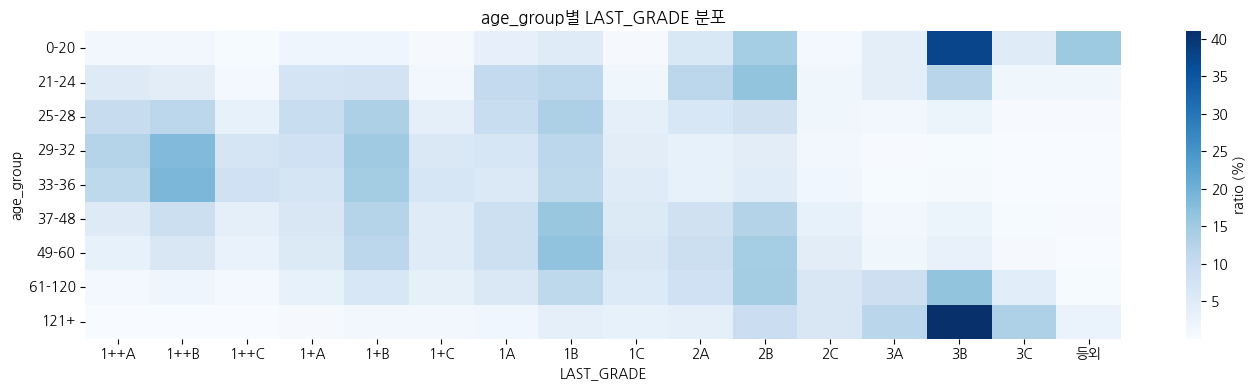

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
sido,,,,,,,,,,,,,,,,
강원특별자치도,8.305125,12.767765,3.878426,7.901925,13.759100,4.597911,7.462131,12.020833,3.954230,6.316574,8.091435,2.232954,2.496961,4.802452,1.167122,0.245056
경기도,9.185222,13.673482,4.449041,7.531947,13.185110,4.469117,7.420359,11.826446,3.942927,5.909488,7.528212,1.974031,2.588932,4.922939,1.100004,0.292743
경상남도,8.768578,12.495445,5.456354,6.233934,11.536151,5.274640,6.372805,11.265795,4.800410,5.392335,8.366738,2.690751,2.577980,6.555504,1.635921,0.576660
경상북도,8.654753,14.198814,6.318143,6.710302,13.219984,6.076408,6.778827,12.604913,5.330892,4.576460,7.111378,2.429077,1.734418,3.292323,0.826920,0.136389
광주광역시,7.699501,10.349127,3.678304,7.263092,11.596010,5.143392,7.886534,14.027431,4.769327,7.605985,10.972569,3.273067,2.524938,2.711970,0.498753,0.000000
대구광역시,6.145340,11.977035,4.890755,6.262293,12.955186,6.134708,7.017171,13.438945,5.555260,5.507416,8.654511,3.237467,2.094519,4.662166,1.259901,0.207326
대전광역시,8.176101,10.555100,4.375171,8.586273,10.555100,4.484550,8.121411,11.402789,4.101723,7.273722,9.871479,2.761827,2.925896,5.496308,1.230517,0.082034
부산광역시,4.972376,6.077348,1.657459,3.867403,8.839779,5.524862,6.077348,15.469613,7.734807,10.497238,11.049724,3.314917,6.629834,7.182320,1.104972,0.000000
서울특별시,4.545455,2.272727,0.000000,6.818182,9.090909,2.272727,11.363636,11.363636,0.000000,20.454545,22.727273,0.000000,0.000000,9.090909,0.000000,0.000000


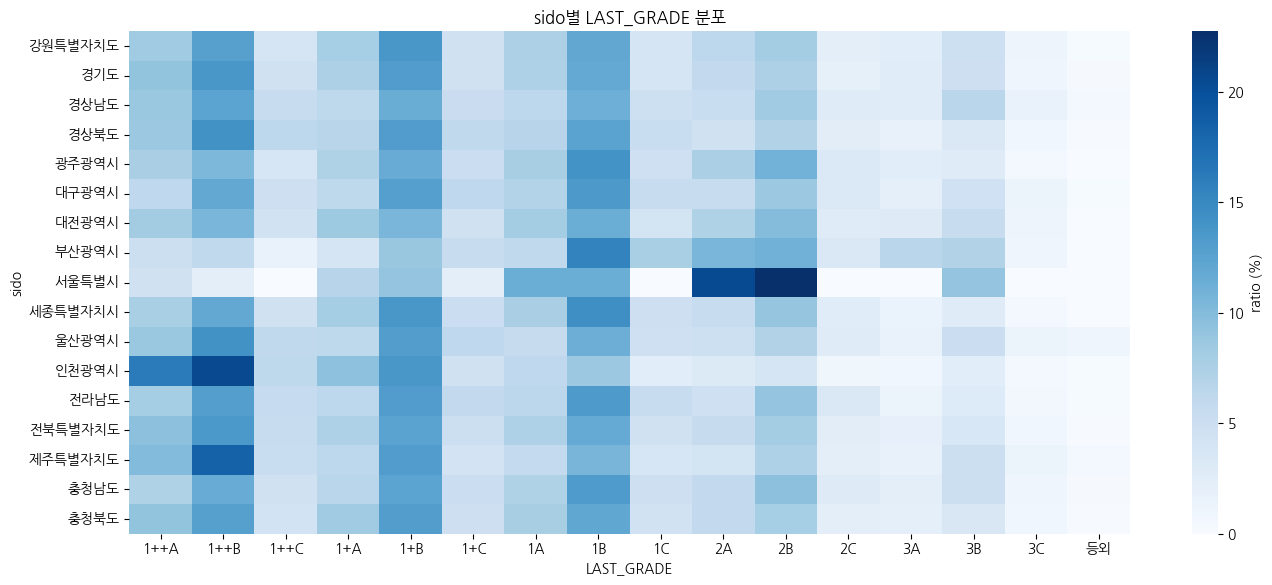

In [ ]:
## 주요 변수별 등급 분포

def plot_grade_by_category(df, col, target=TARGET, top_n=None):
    temp = df[[col, target]].dropna().copy()

    if top_n is not None:
        top_values = temp[col].value_counts().head(top_n).index
        temp = temp[temp[col].isin(top_values)]

    tab = pd.crosstab(temp[col], temp[target], normalize="index") * 100

    display(tab)

    plt.figure(figsize=(14, max(4, len(tab) * 0.35)))
    sns.heatmap(
        tab,
        cmap="Blues",
        cbar_kws={"label": "ratio (%)"}
    )
    plt.title(f"{col}별 LAST_GRADE 분포")
    plt.xlabel("LAST_GRADE")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


if "JUDGE_SEX" in train.columns:
    plot_grade_by_category(train, "JUDGE_SEX")

if "AGE" in train.columns:
    age_bins = [0, 20, 24, 28, 32, 36, 48, 60, 120, 400]
    age_labels = ["0-20", "21-24", "25-28", "29-32", "33-36", "37-48", "49-60", "61-120", "121+"]

    train["age_group"] = pd.cut(
        train["AGE"],
        bins=age_bins,
        labels=age_labels,
        right=True
    )

    plot_grade_by_category(train, "age_group")

if "sido" in train.columns:
    plot_grade_by_category(train, "sido")

,WEIGHT,BACKFAT,REA,INSFAT,AGE
count,2.408699e+06,2.404132e+06,2.403511e+06,2.403368e+06,2.408699e+06
mean,4.227503e+02,1.263125e+01,9.312451e+01,5.423036e+00,4.257461e+01
std,7.984337e+01,5.453570e+00,1.506140e+01,2.199511e+00,2.186101e+01
min,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,3.670000e+02,9.000000e+00,8.400000e+01,4.000000e+00,3.100000e+01
50%,4.230000e+02,1.200000e+01,9.300000e+01,6.000000e+00,3.300000e+01
75%,4.790000e+02,1.500000e+01,1.030000e+02,7.000000e+00,4.700000e+01
max,8.810000e+02,9.800000e+01,1.960000e+02,9.000000e+00,3.440000e+02


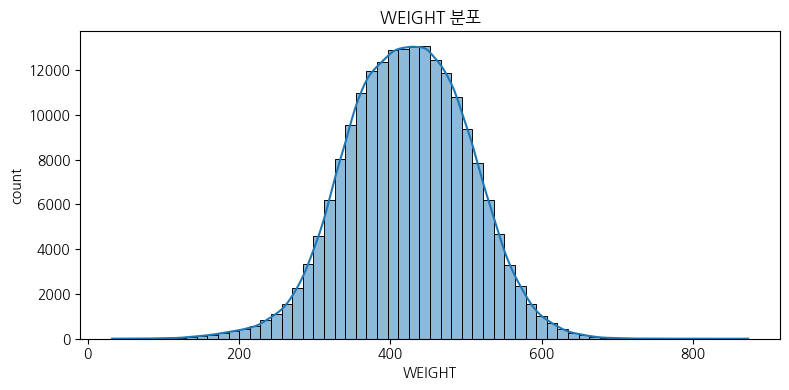

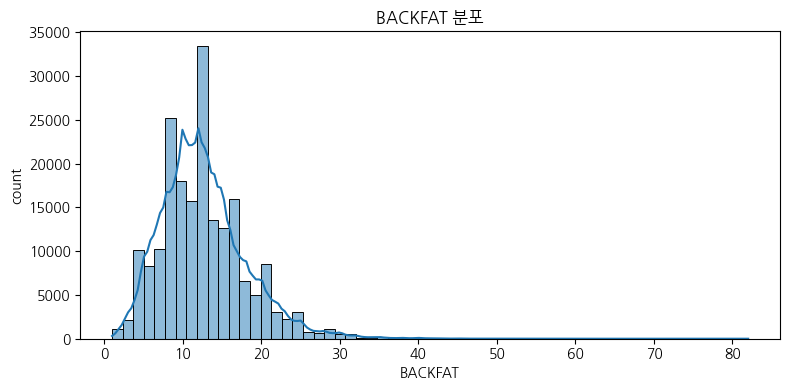

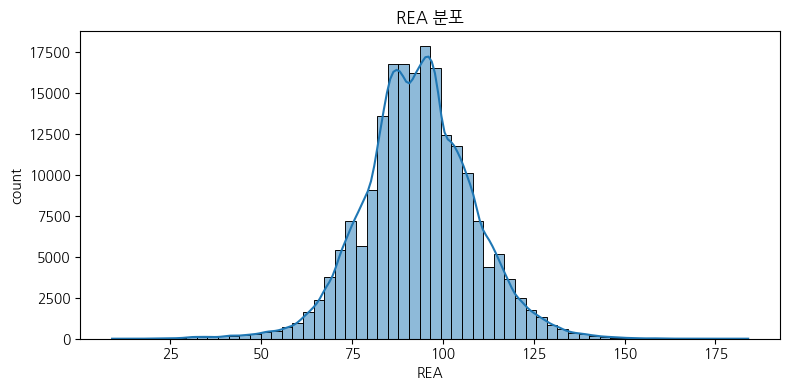

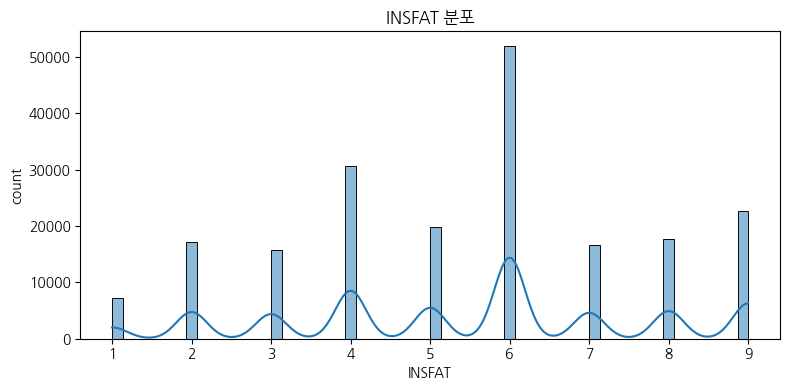

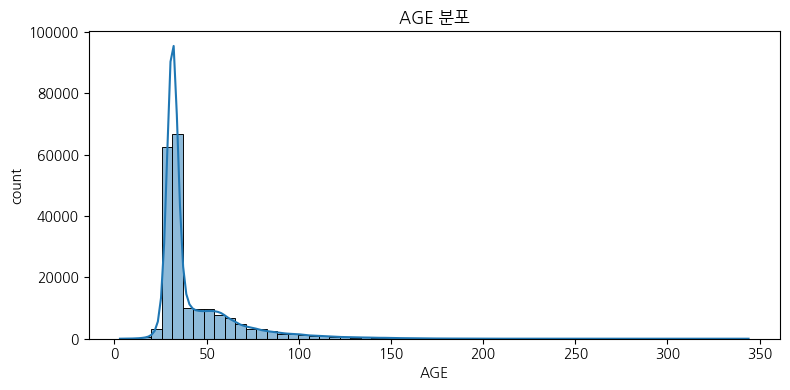

In [ ]:
## 주요 도체 형질 분포
main_numeric_cols = ["WEIGHT", "BACKFAT", "REA", "INSFAT", "AGE"]
main_numeric_cols = [c for c in main_numeric_cols if c in train.columns]

train[main_numeric_cols] = train[main_numeric_cols].replace(-99, np.nan)

train_sample = train.sample(
    n=min(200_000, len(train)),
    random_state=42
)

display(train[main_numeric_cols].describe())

for col in main_numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_sample[col].dropna(), bins=60, kde=True)
    plt.title(f"{col} 분포")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

### 2.2 결측치·이상치 처리

In [ ]:
def replace_minus99_to_nan(df):
    df = df.copy()
    return df.replace([-99, -99.0, "-99", "-99.0"], np.nan)

# 공통 결측 코드 처리
train = replace_minus99_to_nan(train)
test = replace_minus99_to_nan(test)
weather = replace_minus99_to_nan(weather)
area = replace_minus99_to_nan(area)
death = replace_minus99_to_nan(death)
lineage = replace_minus99_to_nan(lineage)

#### 2.2.1 train/test 기본 결측 처리

In [ ]:
# ============================================================
# 2.2.1 train 기본 결측 처리
# - train only
# - DROP_COLS는 처리하지 않고 제거
# - area/weather/lineage는 아직 처리하지 않음
# ============================================================

import numpy as np
import pandas as pd
import gc
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 0. 설정
# ============================================================

TARGET_COL = "LAST_GRADE"
CAT_MISSING = "__MISSING__"

DROP_COLS = [
    "BACKFAT", "FATSAK", "GROWTH", "INSFAT",
    "REA", "TISSUE", "WGRADE", "WINDEX", "YUKSAK",
    "COST_AMT",
    "year", "age_group"
]

MISSING_TOKENS = [
    "", " ", "  ",
    "NA", "N/A", "na", "n/a",
    "NaN", "nan",
    "NULL", "null",
    "None", "none",
    "-", "--",
    "-99", "-99.0", -99, -99.0
]

DATE_CANDIDATES = [
    "ABATT_DATE",
    "JUDGE_DATE",
    "BIRTH_DATE"
]


# ============================================================
# 1. 원본 복사
# ============================================================

train_basic = train.copy()

print("[2.2.1] train 기본 결측 처리 시작")
print("Before:", train_basic.shape)


# ============================================================
# 2. 사용하지 않을 컬럼 먼저 제거
# ============================================================

drop_existing = [c for c in DROP_COLS if c in train_basic.columns]

train_basic = train_basic.drop(columns=drop_existing)

print("\n[DROP COLS]")
print("dropped:", drop_existing)
print("After drop:", train_basic.shape)


# ============================================================
# 3. 결측 표현 통일
# ============================================================

train_basic = train_basic.replace(MISSING_TOKENS, np.nan)
train_basic = train_basic.replace([np.inf, -np.inf], np.nan)

object_cols = train_basic.select_dtypes(include=["object", "string"]).columns.tolist()

for col in object_cols:
    train_basic[col] = train_basic[col].astype("object")

    notna_mask = train_basic[col].notna()
    train_basic.loc[notna_mask, col] = (
        train_basic.loc[notna_mask, col]
        .astype(str)
        .str.strip()
    )

    train_basic[col] = train_basic[col].replace(MISSING_TOKENS, np.nan)


# ============================================================
# 4. 날짜 컬럼 처리
# - 날짜는 문자열 결측값으로 채우지 않음
# - 이후 feature engineering에서 year/month/day 생성
# ============================================================

date_cols = [
    c for c in DATE_CANDIDATES
    if c in train_basic.columns
]

for col in date_cols:
    train_basic[col] = pd.to_datetime(train_basic[col], errors="coerce")

print("\n[DATE COLS]")
print(date_cols)


# ============================================================
# 5. target 결측 제거
# ============================================================

if TARGET_COL in train_basic.columns:
    target_missing = train_basic[TARGET_COL].isna().sum()
    print("\n[TARGET CHECK]")
    print("target missing:", target_missing)

    if target_missing > 0:
        train_basic = (
            train_basic
            .loc[train_basic[TARGET_COL].notna()]
            .reset_index(drop=True)
        )
        print("After target missing drop:", train_basic.shape)
else:
    raise ValueError(f"{TARGET_COL} 컬럼이 train에 없습니다.")


# ============================================================
# 6. feature column 정의
# - target 제외
# - 날짜 컬럼 제외
# ============================================================

feature_cols = [
    c for c in train_basic.columns
    if c != TARGET_COL and c not in date_cols
]


# ============================================================
# 7. 숫자형으로 변환 가능한 object 컬럼 정리
# - 단, 명백한 ID/지역/성별 컬럼은 제외
# ============================================================

force_categorical_cols = [
    "CATTLE_NO",
    "FARM_ID",
    "KPN_NO",
    "JUDGE_SEX",
    "sido",
    "sigungu",
    "eupmyeondong",
    "stn"
]

force_categorical_cols = [
    c for c in force_categorical_cols
    if c in train_basic.columns
]

object_feature_cols = [
    c for c in feature_cols
    if train_basic[c].dtype == "object" and c not in force_categorical_cols
]

for col in object_feature_cols:
    converted = pd.to_numeric(train_basic[col], errors="coerce")

    original_notna = train_basic[col].notna().sum()
    converted_notna = converted.notna().sum()

    if original_notna > 0:
        convert_ratio = converted_notna / original_notna
    else:
        convert_ratio = 0

    if convert_ratio >= 0.95:
        train_basic[col] = converted


# ============================================================
# 8. 수치형 / 범주형 컬럼 분리
# ============================================================

numeric_cols = [
    c for c in feature_cols
    if c in train_basic.columns
    and pd.api.types.is_numeric_dtype(train_basic[c])
]

categorical_cols = [
    c for c in feature_cols
    if c in train_basic.columns
    and c not in numeric_cols
]

print("\n[COLUMN TYPES]")
print("numeric cols    :", len(numeric_cols))
print("categorical cols:", len(categorical_cols))


# ============================================================
# 9. 수치형 결측 처리
# - train median 기준
# - 나중에 test에 동일 적용할 수 있도록 저장
# ============================================================

numeric_fill_values = {}

for col in numeric_cols:
    fill_value = train_basic[col].median()

    if pd.isna(fill_value):
        fill_value = 0

    numeric_fill_values[col] = fill_value
    train_basic[col] = train_basic[col].fillna(fill_value)


# ============================================================
# 10. 범주형 결측 처리
# - 아직 category dtype으로 변환하지 않음
# - merge와 feature engineering 이후 최종 모델 직전에 category 변환
# ============================================================

categorical_fill_values = {}

for col in categorical_cols:
    categorical_fill_values[col] = CAT_MISSING
    train_basic[col] = train_basic[col].astype("object").fillna(CAT_MISSING)


# ============================================================
# 11. 결측 처리 정보 저장
# - 이후 test 처리 시 같은 기준 사용
# ============================================================

basic_impute_info = {
    "drop_cols": DROP_COLS,
    "dropped_existing_cols": drop_existing,
    "target_col": TARGET_COL,
    "date_cols": date_cols,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "numeric_fill_values": numeric_fill_values,
    "categorical_fill_values": categorical_fill_values,
    "cat_missing_value": CAT_MISSING
}


# ============================================================
# 12. 최종 점검
# ============================================================

non_date_check_cols = [
    c for c in train_basic.columns
    if c not in date_cols
]

missing_after = (
    train_basic[non_date_check_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n[AFTER BASIC MISSING HANDLING]")
print("train_basic:", train_basic.shape)
print("remaining missing except date cols:", int(missing_after.sum()))

if int(missing_after.sum()) > 0:
    print("\n[Remaining missing columns]")
    print(missing_after[missing_after > 0].head(30))

print("\n[DATE MISSING CHECK]")
for col in date_cols:
    print(f"{col}: {train_basic[col].isna().sum()}")

print("\n[REMOVED COLUMN CHECK]")
still_exists = [c for c in DROP_COLS if c in train_basic.columns]
print("still exists:", still_exists)

gc.collect()

In [ ]:
train = train_basic.copy()

In [ ]:
# 예측 모델에 사용하기 위함
for df in [train, test]:
    date_col = "JUDGE_DATE" if "JUDGE_DATE" in df.columns else "ABATT_DATE"
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    df["JUDGE_YEAR"] = df[date_col].dt.year
    df["JUDGE_MONTH"] = df[date_col].dt.month

    if "AGE" in df.columns:
        df["age_bin"] = pd.cut(
            df["AGE"],
            bins=[0, 24, 30, 36, 42, 60, 999],
            labels=["<=24", "25-30", "31-36", "37-42", "43-60", "60+"],
            right=True
        )

train_only_post_cols = [
    "BACKFAT", "FATSAK", "GROWTH", "INSFAT",
    "REA", "TISSUE", "WGRADE", "WINDEX", "YUKSAK"
]

train = train.drop(
    columns=[c for c in train_only_post_cols if c in train.columns and c not in test.columns],
    errors="ignore"
)

print("train:", train.shape)
print("test :", test.shape)
print("train/test 공통 컬럼 수:", len(set(train.columns) & set(test.columns)))
print("train-only 사후변수 제거 완료")

train: (2408699, 19)
test : (452497, 16)
train/test 공통 컬럼 수: 16
train-only 사후변수 제거 완료


#### 2.2.2 area 결측 처리

In [ ]:
# ============================================================
# 2.2.2 area 결측 처리
# - area only
# - FARM_UNIQUE_NO 기준 1 row로 집계
# - C2023~C2025 사육두수 결측 처리
# - AREA 결측 LightGBM + fallback 처리
# - 최종 area_final 생성
# ============================================================

import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor


# ============================================================
# 0. 설정
# ============================================================

AREA_ID_COL = "FARM_UNIQUE_NO"
AREA_COL = "AREA"
SCALE_COLS = ["C2023", "C2024", "C2025"]

MISSING_TOKENS = [
    "", " ", "  ",
    "NA", "N/A", "na", "n/a",
    "NaN", "nan",
    "NULL", "null",
    "None", "none",
    "-", "--",
    "-99", "-99.0", -99, -99.0
]

RANDOM_STATE = 42


# ============================================================
# 1. area 원본 복사 및 필수 컬럼 확인
# ============================================================

area_work = area.copy()

required_cols = [AREA_ID_COL, AREA_COL] + SCALE_COLS
missing_required_cols = [c for c in required_cols if c not in area_work.columns]

if missing_required_cols:
    raise ValueError(f"area에 필요한 컬럼이 없습니다: {missing_required_cols}")

print("[2.2.2] area 결측 처리 시작")
print("area raw:", area_work.shape)


# ============================================================
# 2. FARM_UNIQUE_NO 정리
# ============================================================

area_work[AREA_ID_COL] = (
    area_work[AREA_ID_COL]
    .astype("string")
    .str.strip()
    .replace({
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "<NA>": pd.NA
    })
)

area_work = area_work.loc[area_work[AREA_ID_COL].notna()].copy()


# ============================================================
# 3. 결측 표현 및 숫자형 정리
# ============================================================

area_work = area_work.replace(MISSING_TOKENS, np.nan)
area_work = area_work.replace([np.inf, -np.inf], np.nan)

for col in SCALE_COLS + [AREA_COL]:
    area_work[col] = pd.to_numeric(area_work[col], errors="coerce")

# 사육두수는 음수만 invalid 처리, 0은 유지
for col in SCALE_COLS:
    area_work.loc[area_work[col] < 0, col] = np.nan

# AREA는 0 이하를 invalid 처리
area_work.loc[area_work[AREA_COL] <= 0, AREA_COL] = np.nan


# ============================================================
# 4. 정리 후 exact duplicate 제거
# ============================================================

area_work = area_work.drop_duplicates().copy()

print("area cleaned:", area_work.shape)


# ============================================================
# 5. 원본 결측 flag 생성
# ============================================================

area_work["scale_info_missing_row"] = (
    area_work[SCALE_COLS].isna().any(axis=1).astype("int8")
)

area_work["area_missing_row"] = (
    area_work[AREA_COL].isna().astype("int8")
)


# ============================================================
# 6. FARM_UNIQUE_NO 단위 집계
# ============================================================

def sum_min_count(x):
    return x.sum(min_count=1)


area_agg = (
    area_work
    .groupby(AREA_ID_COL, as_index=False)
    .agg(
        C2023=("C2023", sum_min_count),
        C2024=("C2024", sum_min_count),
        C2025=("C2025", sum_min_count),

        AREA_max=(AREA_COL, "max"),

        n_area_rows=(AREA_ID_COL, "size"),
        scale_info_missing=("scale_info_missing_row", "max"),
        area_missing_any_row=("area_missing_row", "max")
    )
)

area_agg["multi_area_row_flag"] = (
    area_agg["n_area_rows"] > 1
).astype("int8")

# 최종적으로 AREA 대체가 필요한 농장 여부
area_agg["area_missing"] = (
    area_agg["AREA_max"].isna()
).astype("int8")

area_agg["scale_info_missing"] = (
    area_agg["scale_info_missing"] > 0
).astype("int8")

area_agg["area_missing_any_row"] = (
    area_agg["area_missing_any_row"] > 0
).astype("int8")


# ============================================================
# 7. C2023~C2025 사육두수 결측 처리
# - 연도 방향 보간
# - 그래도 남으면 해당 연도 median
# - 그래도 남으면 0
# ============================================================

area_agg[SCALE_COLS] = (
    area_agg[SCALE_COLS]
    .interpolate(axis=1, limit_direction="both")
)

scale_fill_values = {}

for col in SCALE_COLS:
    fill_value = area_agg[col].median()

    if pd.isna(fill_value):
        fill_value = 0

    scale_fill_values[col] = fill_value

    area_agg[col] = (
        area_agg[col]
        .fillna(fill_value)
        .round()
        .clip(lower=0)
        .astype("float32")
    )


# ============================================================
# 8. 사육규모 파생변수 생성
# ============================================================

area_agg["scale_avg"] = (
    area_agg[SCALE_COLS].mean(axis=1).astype("float32")
)

area_agg["scale_max"] = (
    area_agg[SCALE_COLS].max(axis=1).astype("float32")
)

area_agg["scale_min"] = (
    area_agg[SCALE_COLS].min(axis=1).astype("float32")
)

area_agg["scale_std"] = (
    area_agg[SCALE_COLS]
    .std(axis=1)
    .fillna(0)
    .astype("float32")
)

area_agg["scale_range"] = (
    area_agg["scale_max"] - area_agg["scale_min"]
).astype("float32")

area_agg["scale_change_23_25"] = (
    area_agg["C2025"] - area_agg["C2023"]
).astype("float32")

area_agg["scale_change_23_24"] = (
    area_agg["C2024"] - area_agg["C2023"]
).astype("float32")

area_agg["scale_change_24_25"] = (
    area_agg["C2025"] - area_agg["C2024"]
).astype("float32")

area_agg["scale_increased"] = (
    area_agg["C2025"] > area_agg["C2023"]
).astype("int8")

area_agg["scale_decreased"] = (
    area_agg["C2025"] < area_agg["C2023"]
).astype("int8")

area_agg["scale_ratio_25_23"] = (
    area_agg["C2025"] / area_agg["C2023"].replace(0, np.nan)
)

area_agg["scale_ratio_25_23"] = (
    area_agg["scale_ratio_25_23"]
    .replace([np.inf, -np.inf], np.nan)
)

scale_ratio_fill = area_agg["scale_ratio_25_23"].median()

if pd.isna(scale_ratio_fill):
    scale_ratio_fill = 1.0

area_agg["scale_ratio_25_23"] = (
    area_agg["scale_ratio_25_23"]
    .fillna(scale_ratio_fill)
    .astype("float32")
)

area_agg["scale_growth_23_25"] = (
    area_agg["scale_change_23_25"] / area_agg["C2023"].replace(0, np.nan)
)

area_agg["scale_growth_23_25"] = (
    area_agg["scale_growth_23_25"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype("float32")
)

area_agg["log1p_scale_avg"] = np.log1p(area_agg["scale_avg"]).astype("float32")
area_agg["log1p_scale_max"] = np.log1p(area_agg["scale_max"]).astype("float32")


# ============================================================
# 9. AREA 결측 LightGBM 예측 대체
# ============================================================

area_model_features = [
    "C2023", "C2024", "C2025",
    "scale_avg", "scale_max", "scale_min", "scale_std", "scale_range",
    "scale_change_23_25", "scale_change_23_24", "scale_change_24_25",
    "scale_ratio_25_23", "scale_growth_23_25",
    "scale_increased", "scale_decreased",
    "log1p_scale_avg", "log1p_scale_max",
    "n_area_rows", "multi_area_row_flag", "scale_info_missing"
]

area_model_features = [
    c for c in area_model_features
    if c in area_agg.columns
]

area_agg["AREA_final"] = area_agg["AREA_max"]
area_agg["area_model_imputed"] = 0
area_agg["AREA_impute_method"] = np.where(
    area_agg["area_missing"].eq(1),
    "missing_not_imputed",
    "observed"
)

obs_mask = area_agg["AREA_final"].notna()
miss_mask = area_agg["AREA_final"].isna()

print("\n[AREA imputation]")
print("AREA observed:", int(obs_mask.sum()))
print("AREA missing :", int(miss_mask.sum()))
print("area model features:", len(area_model_features))

if obs_mask.sum() > 10 and miss_mask.sum() > 0:

    area_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMRegressor(
            n_estimators=600,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    area_model.fit(
        area_agg.loc[obs_mask, area_model_features],
        np.log1p(area_agg.loc[obs_mask, "AREA_final"])
    )

    pred_area = np.expm1(
        area_model.predict(area_agg.loc[miss_mask, area_model_features])
    )

    pred_area = np.clip(pred_area, a_min=0, a_max=None)

    area_agg.loc[miss_mask, "AREA_final"] = pred_area.astype("float32")
    area_agg.loc[miss_mask, "area_model_imputed"] = 1
    area_agg.loc[miss_mask, "AREA_impute_method"] = "lightgbm_log1p_imputed"


# ============================================================
# 10. AREA fallback
# - 모델 예측이 안 됐거나 남은 결측은 median으로 대체
# ============================================================

area_fill_value = area_agg["AREA_final"].median()

if pd.isna(area_fill_value):
    area_fill_value = 0

fallback_mask = area_agg["AREA_final"].isna()

if fallback_mask.any():
    area_agg.loc[fallback_mask, "AREA_final"] = area_fill_value
    area_agg.loc[fallback_mask, "AREA_impute_method"] = "global_median_area_fallback"

area_agg["AREA_final"] = (
    area_agg["AREA_final"]
    .fillna(area_fill_value)
    .clip(lower=0)
    .astype("float32")
)


# ============================================================
# 11. 면적 기반 파생변수 생성
# ============================================================

area_agg["area_per_head"] = (
    area_agg["AREA_final"] / area_agg["scale_avg"].replace(0, np.nan)
)

area_agg["head_per_area"] = (
    area_agg["scale_avg"] / area_agg["AREA_final"].replace(0, np.nan)
)

for col in ["area_per_head", "head_per_area"]:
    area_agg[col] = (
        area_agg[col]
        .replace([np.inf, -np.inf], np.nan)
    )

    fill_value = area_agg[col].median()

    if pd.isna(fill_value):
        fill_value = 0

    area_agg[col] = (
        area_agg[col]
        .fillna(fill_value)
        .clip(lower=0)
        .astype("float32")
    )

area_agg["log1p_area_final"] = np.log1p(area_agg["AREA_final"]).astype("float32")
area_agg["log1p_area_per_head"] = np.log1p(area_agg["area_per_head"]).astype("float32")
area_agg["log1p_head_per_area"] = np.log1p(area_agg["head_per_area"]).astype("float32")


# ============================================================
# 12. 최종 area_final 생성
# ============================================================

area_final_cols = [
    AREA_ID_COL,

    "C2023", "C2024", "C2025",

    "scale_avg",
    "scale_max",
    "scale_min",
    "scale_std",
    "scale_range",
    "scale_change_23_25",
    "scale_change_23_24",
    "scale_change_24_25",
    "scale_ratio_25_23",
    "scale_growth_23_25",
    "scale_increased",
    "scale_decreased",
    "log1p_scale_avg",
    "log1p_scale_max",

    "AREA_final",
    "log1p_area_final",
    "area_per_head",
    "log1p_area_per_head",
    "head_per_area",
    "log1p_head_per_area",

    "n_area_rows",
    "multi_area_row_flag",
    "area_missing",
    "area_missing_any_row",
    "area_model_imputed",
    "scale_info_missing"
]

area_final_cols = [
    c for c in area_final_cols
    if c in area_agg.columns
]

area_final = area_agg[area_final_cols].copy()


# ============================================================
# 13. 최종 검증
# ============================================================

dup_cnt = area_final.duplicated(AREA_ID_COL).sum()
missing_cnt = int(area_final.isna().sum().sum())

print("\n[2.2.2] area 결측 처리 완료")
print("area_final:", area_final.shape)
print("duplicated FARM_UNIQUE_NO:", dup_cnt)
print("total missing:", missing_cnt)

if dup_cnt > 0:
    raise ValueError("area_final이 FARM_UNIQUE_NO 기준 unique가 아닙니다.")

if missing_cnt > 0:
    print(area_final.isna().sum().sort_values(ascending=False).head(30))
    raise ValueError("area_final에 결측이 남아 있습니다.")

print("\n[AREA_impute_method]")
print(area_agg["AREA_impute_method"].value_counts(dropna=False))

gc.collect()

#### 2.2.3 weather 결측 처리

In [ ]:
# ============================================================
# 2.2.3 weather 결측 처리
# - weather only
# - ASOS/AWS station meta merge
# - short gap time interpolation
# - IDW spatial interpolation
# - station-month median / global-month median fallback
# - final weather_final 생성
# ============================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


# ============================================================
# 0. 설정
# ============================================================

# DATA_DIR가 이미 위에서 정의되어 있으면 그대로 사용
# 예시:
# DATA_DIR = "/content/drive/MyDrive/2026_기상청_축산/hanwoo"

WEATHER_PATH = f"{DATA_DIR}/hanwoo_weather.csv"
AWS_META_PATH = f"{DATA_DIR}/aws_new.csv"
ASOS_META_PATH = f"{DATA_DIR}/asos_new.csv"

WEATHER_COLS = ["ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"]
TIME_INTERP_COLS = ["ta_max", "ta_min", "rhm_avg", "ws_davg"]

LONG_MISSING_DAYS = 30
SHORT_GAP_DAYS = 3

IDW_K_DEFAULT = 5
IDW_K_RAIN = 3
IDW_POWER = 2

MISSING_TOKENS = [
    "", " ", "  ",
    "NA", "N/A", "na", "n/a",
    "NaN", "nan",
    "NULL", "null",
    "None", "none",
    "-", "--",
    "-99", "-99.0", -99, -99.0,
    "-999", "-999.0", -999, -999.0
]


# ============================================================
# 1. 데이터 로드
# ============================================================

if "weather" not in globals():
    weather = pd.read_csv(WEATHER_PATH)

aws_new = pd.read_csv(AWS_META_PATH, encoding="cp949")
asos_meta = pd.read_csv(ASOS_META_PATH, encoding="cp949")

weather = weather.copy()
aws_new = aws_new.copy()
asos_meta = asos_meta.copy()

print("[2.2.3] weather 결측 처리 시작")
print("weather raw:", weather.shape)
print("aws_new:", aws_new.shape)
print("asos_meta:", asos_meta.shape)


# ============================================================
# 2. 결측 표현 표준화 함수
# ============================================================

def normalize_missing_tokens(df):
    df = df.copy()

    df = df.replace(MISSING_TOKENS, np.nan)
    df = df.replace([np.inf, -np.inf], np.nan)

    object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

    for col in object_cols:
        df[col] = df[col].astype("object")

        notna_mask = df[col].notna()
        df.loc[notna_mask, col] = (
            df.loc[notna_mask, col]
            .astype(str)
            .str.strip()
        )

        df[col] = df[col].replace(MISSING_TOKENS, np.nan)

    return df


weather = normalize_missing_tokens(weather)
aws_new = normalize_missing_tokens(aws_new)
asos_meta = normalize_missing_tokens(asos_meta)


# ============================================================
# 3. weather 기본 타입 정리
# ============================================================

required_weather_base_cols = ["stn", "date"] + WEATHER_COLS
missing_weather_cols = [
    c for c in required_weather_base_cols
    if c not in weather.columns
]

if missing_weather_cols:
    raise ValueError(f"weather에 필요한 컬럼이 없습니다: {missing_weather_cols}")

weather["stn"] = pd.to_numeric(weather["stn"], errors="coerce")
weather = weather.loc[weather["stn"].notna()].copy()
weather["stn"] = weather["stn"].astype(int)

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
weather = weather.loc[weather["date"].notna()].copy()

for col in WEATHER_COLS:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

# 물리적으로 불가능한 값은 결측으로 돌림
if "rn_day" in weather.columns:
    weather.loc[weather["rn_day"] < 0, "rn_day"] = np.nan

if "rhm_avg" in weather.columns:
    weather.loc[
        (weather["rhm_avg"] < 0) | (weather["rhm_avg"] > 100),
        "rhm_avg"
    ] = np.nan

if "ws_davg" in weather.columns:
    weather.loc[weather["ws_davg"] < 0, "ws_davg"] = np.nan

weather = weather.sort_values(["stn", "date"]).reset_index(drop=True)

print("weather cleaned:", weather.shape)
print("weather unique stn:", weather["stn"].nunique())
print("weather date range:", weather["date"].min(), "~", weather["date"].max())


# ============================================================
# 4. 메타데이터 날짜 파싱 함수
# - 20200101 같은 8자리 날짜도 안전하게 처리
# ============================================================

def parse_station_date(s):
    s = s.copy()

    if pd.api.types.is_numeric_dtype(s):
        s = s.astype("Int64").astype("string")
    else:
        s = s.astype("string").str.strip()

    out = pd.to_datetime(s, errors="coerce")

    eight_digit_mask = s.str.match(r"^\d{8}$", na=False)

    if eight_digit_mask.any():
        out.loc[eight_digit_mask] = pd.to_datetime(
            s.loc[eight_digit_mask],
            format="%Y%m%d",
            errors="coerce"
        )

    return out


# ============================================================
# 5. ASOS/AWS 메타데이터 표준화
# ============================================================

def standardize_station_meta(meta, obs_type):
    meta = meta.copy()
    meta.columns = meta.columns.astype(str).str.strip()

    col_candidates = {
        "stn": ["지점", "지점번호", "stn", "STN", "station_id", "station"],
        "stn_name": ["지점명", "관측소명", "stn_name", "STN_NAME", "station_name"],
        "lat": ["위도", "lat", "LAT", "latitude", "Latitude"],
        "lon": ["경도", "lon", "LON", "longitude", "Longitude"],
        "start_date": ["시작일", "시작일자", "관측시작일", "start_date", "START_DATE"],
        "end_date": ["종료일", "종료일자", "관측종료일", "end_date", "END_DATE"]
    }

    rename_dict = {}

    for std_col, candidates in col_candidates.items():
        for c in candidates:
            if c in meta.columns:
                rename_dict[c] = std_col
                break

    meta = meta.rename(columns=rename_dict)

    required_cols = ["stn", "lat", "lon"]
    missing_required = [c for c in required_cols if c not in meta.columns]

    if missing_required:
        raise ValueError(
            f"{obs_type} 메타데이터에서 필수 컬럼을 찾지 못했습니다: {missing_required}\n"
            f"현재 컬럼: {meta.columns.tolist()}"
        )

    if "stn_name" not in meta.columns:
        meta["stn_name"] = np.nan

    if "start_date" not in meta.columns:
        meta["start_date"] = pd.NaT

    if "end_date" not in meta.columns:
        meta["end_date"] = pd.NaT

    meta["obs_type"] = obs_type
    meta["stn"] = pd.to_numeric(meta["stn"], errors="coerce")
    meta = meta.loc[meta["stn"].notna()].copy()
    meta["stn"] = meta["stn"].astype(int)

    meta["lat"] = pd.to_numeric(meta["lat"], errors="coerce")
    meta["lon"] = pd.to_numeric(meta["lon"], errors="coerce")

    meta["start_date"] = parse_station_date(meta["start_date"])
    meta["end_date"] = parse_station_date(meta["end_date"])
    meta["end_date"] = meta["end_date"].fillna(pd.Timestamp("2099-12-31"))

    meta = meta[
        ["obs_type", "stn", "stn_name", "lat", "lon", "start_date", "end_date"]
    ].copy()

    return meta


asos_meta_std = standardize_station_meta(asos_meta, "ASOS")
aws_meta_std = standardize_station_meta(aws_new, "AWS")


# ============================================================
# 6. weather 관측소 ASOS/AWS 분류
# ============================================================

weather_stn = pd.DataFrame({
    "stn": sorted(weather["stn"].dropna().astype(int).unique())
})

asos_stn = set(
    asos_meta_std
    .loc[asos_meta_std["lat"].notna() & asos_meta_std["lon"].notna(), "stn"]
    .astype(int)
)

aws_stn = set(
    aws_meta_std
    .loc[aws_meta_std["lat"].notna() & aws_meta_std["lon"].notna(), "stn"]
    .astype(int)
)

weather_stn["in_asos"] = weather_stn["stn"].isin(asos_stn)
weather_stn["in_aws"] = weather_stn["stn"].isin(aws_stn)


def classify_station(row):
    if row["in_asos"] and row["in_aws"]:
        return "BOTH"
    if row["in_asos"]:
        return "ASOS"
    if row["in_aws"]:
        return "AWS"
    return np.nan


weather_stn["obs_type"] = weather_stn.apply(classify_station, axis=1)

both_cnt = int((weather_stn["obs_type"] == "BOTH").sum())
unknown_cnt = int(weather_stn["obs_type"].isna().sum())

print("\n[Station type check]")
print(weather_stn["obs_type"].value_counts(dropna=False))
print("BOTH station count:", both_cnt)
print("UNKNOWN station count:", unknown_cnt)

# stn이 ASOS/AWS 양쪽에 모두 존재하는 경우
# 원본에 obs_type이 없으면 ASOS 우선으로 둔다.
# 실제 데이터에서 BOTH가 많으면 원본 출처 기준 재확인이 필요함.
weather_stn.loc[weather_stn["obs_type"] == "BOTH", "obs_type"] = "ASOS"


# ============================================================
# 7. station meta 이력 중 weather 기간과 겹치는 최신 이력 선택
# ============================================================

station_meta = pd.concat([asos_meta_std, aws_meta_std], ignore_index=True)

weather_start = weather["date"].min()
weather_end = weather["date"].max()

station_meta["overlap_weather_period"] = (
    station_meta["start_date"].fillna(pd.Timestamp("1900-01-01")).le(weather_end)
    &
    station_meta["end_date"].fillna(pd.Timestamp("2099-12-31")).ge(weather_start)
)

station_meta_best = (
    station_meta
    .sort_values(
        by=["obs_type", "stn", "overlap_weather_period", "start_date"],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(["obs_type", "stn"], keep="first")
    .drop(columns=["overlap_weather_period"])
    .copy()
)


# ============================================================
# 8. weather + station meta merge
# ============================================================

weather_merged = weather.merge(
    weather_stn[["stn", "obs_type"]],
    on="stn",
    how="left"
)

weather_merged = weather_merged.merge(
    station_meta_best,
    on=["obs_type", "stn"],
    how="left"
)

station_check = (
    weather_merged
    .groupby("stn", as_index=False)
    .agg(
        obs_type=("obs_type", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        stn_name=("stn_name", "first")
    )
)

station_check["coord_matched"] = (
    station_check["lat"].notna() & station_check["lon"].notna()
)

coord_match_rate = station_check["coord_matched"].mean()

print("\n[Coordinate matching]")
print("station count:", station_check["stn"].nunique())
print("matched station:", int(station_check["coord_matched"].sum()))
print("unmatched station:", int((~station_check["coord_matched"]).sum()))
print("station coordinate match rate:", round(coord_match_rate * 100, 2), "%")

if (~station_check["coord_matched"]).sum() > 0:
    unmatched = station_check.loc[
        ~station_check["coord_matched"],
        ["stn", "obs_type", "stn_name", "lat", "lon"]
    ].sort_values("stn")

    print("\n[Unmatched station head]")
    print(unmatched.head(30))

    raise ValueError("좌표 미매칭 관측소가 있습니다. IDW 전에 메타데이터 매칭을 확인해야 합니다.")


# ============================================================
# 9. weather_imp 기본 준비
# ============================================================

weather_imp = weather_merged.copy()

drop_meta_cols = ["stn_name", "start_date", "end_date"]
weather_imp = weather_imp.drop(
    columns=[c for c in drop_meta_cols if c in weather_imp.columns]
)

weather_imp["stn"] = weather_imp["stn"].astype(int)
weather_imp["date"] = pd.to_datetime(weather_imp["date"], errors="coerce")
weather_imp["lat"] = pd.to_numeric(weather_imp["lat"], errors="coerce")
weather_imp["lon"] = pd.to_numeric(weather_imp["lon"], errors="coerce")

for col in WEATHER_COLS:
    weather_imp[col] = pd.to_numeric(weather_imp[col], errors="coerce")

weather_imp = weather_imp.sort_values(["stn", "date"]).reset_index(drop=True)

if weather_imp[["lat", "lon"]].isna().sum().sum() > 0:
    raise ValueError("weather_imp에 lat/lon 결측이 남아 있습니다.")


# ============================================================
# 10. 원결측 flag + 장기결측 flag 생성
# ============================================================

def make_long_missing_flag(s, threshold=30):
    mask = s.isna()
    run_id = (mask != mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform("sum")

    return (mask & (run_len >= threshold)).astype("int8")


for col in WEATHER_COLS:
    weather_imp[f"{col}_raw"] = weather_imp[col]
    weather_imp[f"{col}_missing"] = weather_imp[col].isna().astype("int8")

    weather_imp[f"{col}_long_missing"] = (
        weather_imp
        .groupby("stn")[col]
        .transform(lambda x: make_long_missing_flag(x, LONG_MISSING_DAYS))
        .astype("int8")
    )

    weather_imp[f"{col}_impute_method"] = np.where(
        weather_imp[col].isna(),
        "missing_pending",
        "observed"
    )


# ============================================================
# 11. 3일 이하 short gap만 시간보간
# - rn_day는 강수량이므로 시간보간하지 않음
# ============================================================

def fill_short_gap_only(s, max_gap=3):
    mask = s.isna()
    run_id = (mask != mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform("sum")

    short_gap_mask = mask & (run_len <= max_gap)

    interpolated = s.interpolate(
        method="linear",
        limit_area="inside"
    )

    out = s.copy()
    out.loc[short_gap_mask] = interpolated.loc[short_gap_mask]

    return out


print("\n[Short gap time interpolation]")

for col in TIME_INTERP_COLS:
    before_s = weather_imp[col].copy()

    weather_imp[col] = (
        weather_imp
        .groupby("stn", group_keys=False)[col]
        .apply(lambda x: fill_short_gap_only(x, SHORT_GAP_DAYS))
    )

    filled_mask = before_s.isna() & weather_imp[col].notna()

    weather_imp.loc[filled_mask, f"{col}_impute_method"] = "time_interp_3d"

    print(f"{col}: {int(before_s.isna().sum())} -> {int(weather_imp[col].isna().sum())}")

print("rn_day: skipped")


# ============================================================
# 12. 관측소 간 거리 행렬 생성
# - Haversine distance, km
# ============================================================

station_coord = (
    weather_imp[["stn", "lat", "lon"]]
    .drop_duplicates("stn")
    .sort_values("stn")
    .reset_index(drop=True)
)

station_ids = station_coord["stn"].values
stn_to_idx = {stn: i for i, stn in enumerate(station_ids)}

lat_rad = np.radians(station_coord["lat"].values)
lon_rad = np.radians(station_coord["lon"].values)

R = 6371.0

dlat = lat_rad[:, None] - lat_rad[None, :]
dlon = lon_rad[:, None] - lon_rad[None, :]

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat_rad[:, None])
    * np.cos(lat_rad[None, :])
    * np.sin(dlon / 2) ** 2
)

dist_matrix = 2 * R * np.arcsin(np.sqrt(a))

# 자기 자신 제외
np.fill_diagonal(dist_matrix, np.inf)


# ============================================================
# 13. 같은 날짜 기준 IDW 공간보간 함수
# ============================================================

def idw_fill_by_date(data, col, k=5, power=2):
    data = data.copy()

    for date_value, g in data.groupby("date", sort=False):
        idx = g.index

        miss_idx = idx[data.loc[idx, col].isna()]
        avail_idx = idx[data.loc[idx, col].notna()]

        if len(miss_idx) == 0 or len(avail_idx) == 0:
            continue

        target_stn = data.loc[miss_idx, "stn"].values
        avail_stn = data.loc[avail_idx, "stn"].values
        avail_val = data.loc[avail_idx, col].values.astype(float)

        target_pos = np.array([stn_to_idx[x] for x in target_stn])
        avail_pos = np.array([stn_to_idx[x] for x in avail_stn])

        d = dist_matrix[np.ix_(target_pos, avail_pos)]

        k_eff = min(k, d.shape[1])

        nearest_pos = np.argpartition(d, kth=k_eff - 1, axis=1)[:, :k_eff]
        nearest_d = np.take_along_axis(d, nearest_pos, axis=1)
        nearest_v = avail_val[nearest_pos]

        weights = 1 / np.maximum(nearest_d, 1e-6) ** power

        pred = np.sum(weights * nearest_v, axis=1) / np.sum(weights, axis=1)

        data.loc[miss_idx, col] = pred
        data.loc[miss_idx, f"{col}_impute_method"] = f"idw_k{k_eff}"

    return data


# ============================================================
# 14. IDW 적용
# - 기온/습도/풍속: k=5
# - 강수량: k=3
# ============================================================

print("\n[IDW spatial interpolation]")

for col in ["ta_max", "ta_min", "rhm_avg", "ws_davg"]:
    before = int(weather_imp[col].isna().sum())
    weather_imp = idw_fill_by_date(
        weather_imp,
        col=col,
        k=IDW_K_DEFAULT,
        power=IDW_POWER
    )
    after = int(weather_imp[col].isna().sum())

    print(f"{col}: {before} -> {after}")

before = int(weather_imp["rn_day"].isna().sum())
weather_imp = idw_fill_by_date(
    weather_imp,
    col="rn_day",
    k=IDW_K_RAIN,
    power=IDW_POWER
)
after = int(weather_imp["rn_day"].isna().sum())

print(f"rn_day: {before} -> {after}")


# ============================================================
# 15. fallback 1: 관측소-월 median
# ============================================================

weather_imp["month"] = weather_imp["date"].dt.month

print("\n[Fallback 1: station-month median]")

for col in WEATHER_COLS:
    before = int(weather_imp[col].isna().sum())

    station_month_median = (
        weather_imp
        .groupby(["stn", "month"])[col]
        .transform("median")
    )

    fill_mask = weather_imp[col].isna() & station_month_median.notna()

    weather_imp.loc[fill_mask, col] = station_month_median.loc[fill_mask]
    weather_imp.loc[fill_mask, f"{col}_impute_method"] = "station_month_median"

    after = int(weather_imp[col].isna().sum())

    print(f"{col}: {before} -> {after}")


# ============================================================
# 16. fallback 2: 전체 월 median
# ============================================================

print("\n[Fallback 2: global-month median]")

for col in WEATHER_COLS:
    before = int(weather_imp[col].isna().sum())

    global_month_median = (
        weather_imp
        .groupby("month")[col]
        .transform("median")
    )

    fill_mask = weather_imp[col].isna() & global_month_median.notna()

    weather_imp.loc[fill_mask, col] = global_month_median.loc[fill_mask]
    weather_imp.loc[fill_mask, f"{col}_impute_method"] = "global_month_median"

    after = int(weather_imp[col].isna().sum())

    print(f"{col}: {before} -> {after}")


# ============================================================
# 17. fallback 3: 전체 median
# - 예외적으로 월 median도 없는 경우 방어
# ============================================================

print("\n[Fallback 3: global median]")

for col in WEATHER_COLS:
    before = int(weather_imp[col].isna().sum())

    fill_value = weather_imp[col].median()

    if pd.isna(fill_value):
        fill_value = 0

    fill_mask = weather_imp[col].isna()

    weather_imp.loc[fill_mask, col] = fill_value
    weather_imp.loc[fill_mask, f"{col}_impute_method"] = "global_median"

    after = int(weather_imp[col].isna().sum())

    print(f"{col}: {before} -> {after}")


# ============================================================
# 18. 물리적으로 불가능한 값 보정
# ============================================================

weather_imp["rn_day"] = weather_imp["rn_day"].clip(lower=0)
weather_imp["rhm_avg"] = weather_imp["rhm_avg"].clip(lower=0, upper=100)
weather_imp["ws_davg"] = weather_imp["ws_davg"].clip(lower=0)

# ta_max < ta_min 방어
if {"ta_max", "ta_min"}.issubset(weather_imp.columns):
    swap_mask = weather_imp["ta_max"] < weather_imp["ta_min"]

    if swap_mask.any():
        ta_max_old = weather_imp.loc[swap_mask, "ta_max"].copy()
        weather_imp.loc[swap_mask, "ta_max"] = weather_imp.loc[swap_mask, "ta_min"]
        weather_imp.loc[swap_mask, "ta_min"] = ta_max_old


# ============================================================
# 19. 최종 weather_final 생성
# ============================================================

final_cols = [
    "stn", "date",
    "obs_type", "lat", "lon",

    "ta_max", "ta_min", "rn_day", "rhm_avg", "ws_davg",

    "ta_max_missing", "ta_min_missing", "rn_day_missing",
    "rhm_avg_missing", "ws_davg_missing",

    "ta_max_long_missing", "ta_min_long_missing", "rn_day_long_missing",
    "rhm_avg_long_missing", "ws_davg_long_missing"
]

final_cols = [c for c in final_cols if c in weather_imp.columns]

weather_final = weather_imp[final_cols].copy()
weather_final = weather_final.sort_values(["stn", "date"]).reset_index(drop=True)

for col in WEATHER_COLS:
    weather_final[col] = weather_final[col].astype("float32")

for col in [f"{c}_missing" for c in WEATHER_COLS] + [f"{c}_long_missing" for c in WEATHER_COLS]:
    if col in weather_final.columns:
        weather_final[col] = weather_final[col].astype("int8")


# ============================================================
# 20. 최종 검증
# ============================================================

weather_value_missing = int(weather_final[WEATHER_COLS].isna().sum().sum())
dup_cnt = int(weather_final.duplicated(["stn", "date"]).sum())

print("\n[2.2.3] weather 결측 처리 완료")
print("weather_final:", weather_final.shape)
print("duplicated stn-date:", dup_cnt)
print("weather value missing:", weather_value_missing)

if dup_cnt > 0:
    raise ValueError("weather_final에 stn-date 중복이 있습니다.")

if weather_value_missing > 0:
    print(weather_final[WEATHER_COLS].isna().sum())
    raise ValueError("weather_final의 기상값에 결측이 남아 있습니다.")

print("\n[원결측 count]")
print(weather_final[[f"{c}_missing" for c in WEATHER_COLS]].sum().sort_values(ascending=False))

print("\n[장기결측 count]")
print(weather_final[[f"{c}_long_missing" for c in WEATHER_COLS]].sum().sort_values(ascending=False))

print("\n[최종 기상값 결측]")
print(weather_final[WEATHER_COLS].isna().sum())

gc.collect()

#### 2.2.4 추가 데이터 Lineage 처리

In [ ]:
# ============================================================
# 2.2.4 lineage 필요한 column만 남기기
# - extended lineage feature 포함
# - raw lineage ID는 최종 모델 feature에서 제거
# - CATTLE_NO 기준 merge용 lineage_final 생성
# ============================================================

import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


# ============================================================
# 0. 설정
# ============================================================

LINEAGE_PATH = DATA_DIR / "hanwoo_lineage_0612.csv"

LINEAGE_KEY = "CATTLE_NO"

LINEAGE_KEEP_COLS = [
    "CATTLE_NO",
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

ANCESTOR_COLS = [
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

ROLE_GROUPS = {
    "parent": [
        "FATHER_CATTLE_NO",
        "MOTHER_ANIMAL_NO",
    ],
    "grandparent": [
        "F_GMOTHER_ANIMAL_NO",
        "F_GFATHER_CATTLE_NO",
        "M_GMOTHER_ANIMAL_NO",
        "M_GFATHER_CATTLE_NO",
    ],
    "paternal": [
        "FATHER_CATTLE_NO",
        "F_GMOTHER_ANIMAL_NO",
        "F_GFATHER_CATTLE_NO",
    ],
    "maternal": [
        "MOTHER_ANIMAL_NO",
        "M_GMOTHER_ANIMAL_NO",
        "M_GFATHER_CATTLE_NO",
    ],
    "grandsire": [
        "F_GFATHER_CATTLE_NO",
        "M_GFATHER_CATTLE_NO",
    ],
    "granddam": [
        "F_GMOTHER_ANIMAL_NO",
        "M_GMOTHER_ANIMAL_NO",
    ],
}

MISSING_TOKENS = {
    "": pd.NA,
    " ": pd.NA,
    "  ": pd.NA,
    "nan": pd.NA,
    "NaN": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "None": pd.NA,
    "NULL": pd.NA,
    "<NA>": pd.NA,
}


# ============================================================
# 1. helper
# ============================================================

def read_csv_safely(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass

    raise ValueError(f"CSV 로드 실패: {path}")


def clean_key(s):
    s = s.astype("string").str.strip()
    s = s.replace(MISSING_TOKENS)
    return s


def eq_non_missing(df, col_a, col_b):
    return (
        df[col_a].notna()
        & df[col_b].notna()
        & df[col_a].eq(df[col_b])
    ).astype("int8")


def safe_mean_positive(df, cols):
    valid_cols = [c for c in cols if c in df.columns]

    if len(valid_cols) == 0:
        return pd.Series(0, index=df.index, dtype="float32")

    out = (
        df[valid_cols]
        .replace(0, np.nan)
        .mean(axis=1)
        .fillna(0)
        .astype("float32")
    )

    return out


def safe_max(df, cols):
    valid_cols = [c for c in cols if c in df.columns]

    if len(valid_cols) == 0:
        return pd.Series(0, index=df.index, dtype="float32")

    out = (
        df[valid_cols]
        .max(axis=1)
        .fillna(0)
        .astype("float32")
    )

    return out


def downcast_numeric(df, cols):
    for col in cols:
        if col not in df.columns:
            continue

        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].astype("float32")

        elif pd.api.types.is_integer_dtype(df[col]):
            max_v = df[col].max()
            min_v = df[col].min()

            if min_v >= -128 and max_v <= 127:
                df[col] = df[col].astype("int8")
            elif min_v >= -32768 and max_v <= 32767:
                df[col] = df[col].astype("int16")
            else:
                df[col] = df[col].astype("int32")

    return df


# ============================================================
# 2. lineage 로드 및 기본 정리
# ============================================================

lineage_raw = read_csv_safely(LINEAGE_PATH)

missing_cols = [
    c for c in LINEAGE_KEEP_COLS
    if c not in lineage_raw.columns
]

if missing_cols:
    raise ValueError(f"lineage에 필요한 컬럼이 없습니다: {missing_cols}")

lineage_work = lineage_raw[LINEAGE_KEEP_COLS].copy()

for col in LINEAGE_KEEP_COLS:
    lineage_work[col] = clean_key(lineage_work[col])

lineage_work = lineage_work.loc[lineage_work[LINEAGE_KEY].notna()].copy()

lineage_work = (
    lineage_work
    .drop_duplicates(LINEAGE_KEY, keep="first")
    .reset_index(drop=True)
)

print("[2.2.4] lineage extended feature 생성 시작")
print("lineage_raw :", lineage_raw.shape)
print("lineage_work:", lineage_work.shape)
print("duplicated CATTLE_NO:", int(lineage_work.duplicated(LINEAGE_KEY).sum()))


# ============================================================
# 3. 작업용 lineage_feat 생성
# - raw ID는 여기서만 사용
# - 최종 lineage_final에는 raw ID를 제거
# ============================================================

lineage_feat = lineage_work.copy()
lineage_feature_cols = []


# ============================================================
# 4. 기본 feature: has / freq / log1p_freq
# ============================================================

for col in ANCESTOR_COLS:
    prefix = col.lower()

    freq_col = f"{prefix}_freq_all"
    log_col = f"log1p_{prefix}_freq_all"
    has_col = f"has_{prefix}"

    freq_map = lineage_feat[col].value_counts(dropna=True)

    lineage_feat[freq_col] = (
        lineage_feat[col]
        .map(freq_map)
        .fillna(0)
        .astype("int32")
    )

    lineage_feat[log_col] = (
        np.log1p(lineage_feat[freq_col])
        .astype("float32")
    )

    lineage_feat[has_col] = (
        lineage_feat[col]
        .notna()
        .astype("int8")
    )

    lineage_feature_cols.extend([
        freq_col,
        log_col,
        has_col,
    ])


# ============================================================
# 5. extended 1: 혈통 정보 완성도
# ============================================================

has_cols = [f"has_{c.lower()}" for c in ANCESTOR_COLS]

lineage_feat["lineage_known_ancestor_count"] = (
    lineage_feat[has_cols]
    .sum(axis=1)
    .astype("int8")
)

lineage_feat["lineage_known_parent_count"] = (
    lineage_feat[[f"has_{c.lower()}" for c in ROLE_GROUPS["parent"]]]
    .sum(axis=1)
    .astype("int8")
)

lineage_feat["lineage_known_grandparent_count"] = (
    lineage_feat[[f"has_{c.lower()}" for c in ROLE_GROUPS["grandparent"]]]
    .sum(axis=1)
    .astype("int8")
)

lineage_feat["lineage_paternal_known_count"] = (
    lineage_feat[[f"has_{c.lower()}" for c in ROLE_GROUPS["paternal"]]]
    .sum(axis=1)
    .astype("int8")
)

lineage_feat["lineage_maternal_known_count"] = (
    lineage_feat[[f"has_{c.lower()}" for c in ROLE_GROUPS["maternal"]]]
    .sum(axis=1)
    .astype("int8")
)

lineage_feat["lineage_parent_complete"] = (
    lineage_feat["lineage_known_parent_count"].eq(2)
).astype("int8")

lineage_feat["lineage_grandparent_complete"] = (
    lineage_feat["lineage_known_grandparent_count"].eq(4)
).astype("int8")

lineage_feat["lineage_2gen_complete"] = (
    lineage_feat["lineage_known_ancestor_count"].eq(len(ANCESTOR_COLS))
).astype("int8")

lineage_feat["lineage_paternal_known_ratio"] = (
    lineage_feat["lineage_paternal_known_count"] / len(ROLE_GROUPS["paternal"])
).astype("float32")

lineage_feat["lineage_maternal_known_ratio"] = (
    lineage_feat["lineage_maternal_known_count"] / len(ROLE_GROUPS["maternal"])
).astype("float32")

lineage_feat["lineage_depth_score"] = (
    lineage_feat["lineage_known_parent_count"] / 2.0
    + 0.5 * lineage_feat["lineage_known_grandparent_count"] / 4.0
).astype("float32")

lineage_feature_cols.extend([
    "lineage_known_ancestor_count",
    "lineage_known_parent_count",
    "lineage_known_grandparent_count",
    "lineage_paternal_known_count",
    "lineage_maternal_known_count",
    "lineage_parent_complete",
    "lineage_grandparent_complete",
    "lineage_2gen_complete",
    "lineage_paternal_known_ratio",
    "lineage_maternal_known_ratio",
    "lineage_depth_score",
])


# ============================================================
# 6. extended 2: 부계/모계/조부모 role별 frequency aggregate
# ============================================================

for group_name, cols in ROLE_GROUPS.items():
    role_freq_cols = [f"{c.lower()}_freq_all" for c in cols]
    role_log_cols = [f"log1p_{c.lower()}_freq_all" for c in cols]

    mean_freq_col = f"lineage_{group_name}_mean_freq"
    max_freq_col = f"lineage_{group_name}_max_freq"
    mean_log_col = f"lineage_{group_name}_mean_log_freq"
    max_log_col = f"lineage_{group_name}_max_log_freq"

    lineage_feat[mean_freq_col] = safe_mean_positive(lineage_feat, role_freq_cols)
    lineage_feat[max_freq_col] = safe_max(lineage_feat, role_freq_cols)
    lineage_feat[mean_log_col] = safe_mean_positive(lineage_feat, role_log_cols)
    lineage_feat[max_log_col] = safe_max(lineage_feat, role_log_cols)

    lineage_feature_cols.extend([
        mean_freq_col,
        max_freq_col,
        mean_log_col,
        max_log_col,
    ])

lineage_feat["lineage_paternal_minus_maternal_log_freq"] = (
    lineage_feat["lineage_paternal_mean_log_freq"]
    - lineage_feat["lineage_maternal_mean_log_freq"]
).astype("float32")

lineage_feat["lineage_grandsire_minus_granddam_log_freq"] = (
    lineage_feat["lineage_grandsire_mean_log_freq"]
    - lineage_feat["lineage_granddam_mean_log_freq"]
).astype("float32")

lineage_feat["lineage_sire_popularity_score"] = (
    lineage_feat["log1p_kpn_no_freq_all"]
    + lineage_feat["log1p_father_cattle_no_freq_all"]
    + 0.5 * lineage_feat["log1p_f_gfather_cattle_no_freq_all"]
    + 0.5 * lineage_feat["log1p_m_gfather_cattle_no_freq_all"]
).astype("float32")

lineage_feat["lineage_damline_popularity_score"] = (
    lineage_feat["log1p_mother_animal_no_freq_all"]
    + 0.5 * lineage_feat["log1p_m_gmother_animal_no_freq_all"]
    + 0.5 * lineage_feat["log1p_m_gfather_cattle_no_freq_all"]
).astype("float32")

lineage_feature_cols.extend([
    "lineage_paternal_minus_maternal_log_freq",
    "lineage_grandsire_minus_granddam_log_freq",
    "lineage_sire_popularity_score",
    "lineage_damline_popularity_score",
])


# ============================================================
# 7. extended 3: 조상 중복 기반 근교 위험 proxy
# - 실제 inbreeding coefficient는 아님
# - 같은 조상 ID 반복 등장 여부를 proxy로 사용
# ============================================================

lineage_feat["lineage_unique_ancestor_count"] = (
    lineage_feat[ANCESTOR_COLS]
    .nunique(axis=1, dropna=True)
    .astype("int8")
)

lineage_feat["lineage_duplicate_ancestor_count"] = (
    lineage_feat["lineage_known_ancestor_count"]
    - lineage_feat["lineage_unique_ancestor_count"]
).clip(lower=0).astype("int8")

lineage_feat["lineage_any_duplicate_ancestor"] = (
    lineage_feat["lineage_duplicate_ancestor_count"].gt(0)
).astype("int8")

lineage_feat["lineage_duplicate_ancestor_ratio"] = (
    lineage_feat["lineage_duplicate_ancestor_count"]
    / lineage_feat["lineage_known_ancestor_count"].replace(0, np.nan)
).fillna(0).astype("float32")

lineage_feat["lineage_father_eq_mgsire"] = eq_non_missing(
    lineage_feat,
    "FATHER_CATTLE_NO",
    "M_GFATHER_CATTLE_NO"
)

lineage_feat["lineage_paternal_grandsire_eq_maternal_grandsire"] = eq_non_missing(
    lineage_feat,
    "F_GFATHER_CATTLE_NO",
    "M_GFATHER_CATTLE_NO"
)

lineage_feat["lineage_paternal_granddam_eq_maternal_granddam"] = eq_non_missing(
    lineage_feat,
    "F_GMOTHER_ANIMAL_NO",
    "M_GMOTHER_ANIMAL_NO"
)

lineage_feat["lineage_parent_same_id"] = eq_non_missing(
    lineage_feat,
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO"
)

lineage_feature_cols.extend([
    "lineage_unique_ancestor_count",
    "lineage_duplicate_ancestor_count",
    "lineage_any_duplicate_ancestor",
    "lineage_duplicate_ancestor_ratio",
    "lineage_father_eq_mgsire",
    "lineage_paternal_grandsire_eq_maternal_grandsire",
    "lineage_paternal_granddam_eq_maternal_granddam",
    "lineage_parent_same_id",
])


# ============================================================
# 8. extended 4: 전체 ancestor role 통합 global frequency
# - 특정 ID가 어떤 역할에서든 얼마나 자주 등장하는지
# ============================================================

all_ancestor_values = pd.concat(
    [lineage_feat[c] for c in ANCESTOR_COLS],
    axis=0,
    ignore_index=True
)

global_freq = all_ancestor_values.value_counts(dropna=True)

global_freq_raw_cols = []
global_freq_log_cols = []

for col in ANCESTOR_COLS:
    prefix = col.lower()

    gfreq_col = f"{prefix}_global_freq_all_roles"
    glog_col = f"log1p_{gfreq_col}"

    lineage_feat[gfreq_col] = (
        lineage_feat[col]
        .map(global_freq)
        .fillna(0)
        .astype("int32")
    )

    lineage_feat[glog_col] = (
        np.log1p(lineage_feat[gfreq_col])
        .astype("float32")
    )

    global_freq_raw_cols.append(gfreq_col)
    global_freq_log_cols.append(glog_col)

lineage_feat["lineage_global_max_freq"] = safe_max(
    lineage_feat,
    global_freq_raw_cols
)

lineage_feat["lineage_global_mean_freq"] = safe_mean_positive(
    lineage_feat,
    global_freq_raw_cols
)

lineage_feat["lineage_global_max_log_freq"] = safe_max(
    lineage_feat,
    global_freq_log_cols
)

lineage_feat["lineage_global_mean_log_freq"] = safe_mean_positive(
    lineage_feat,
    global_freq_log_cols
)

lineage_feature_cols.extend(global_freq_raw_cols)
lineage_feature_cols.extend(global_freq_log_cols)
lineage_feature_cols.extend([
    "lineage_global_max_freq",
    "lineage_global_mean_freq",
    "lineage_global_max_log_freq",
    "lineage_global_mean_log_freq",
])


# ============================================================
# 9. 최종 lineage_final 생성
# - raw lineage ID 제거
# - CATTLE_NO + 숫자형 파생변수만 유지
# ============================================================

lineage_feature_cols = sorted(set(lineage_feature_cols))

lineage_final = lineage_feat[[LINEAGE_KEY] + lineage_feature_cols].copy()

# 결측 방어
for col in lineage_feature_cols:
    lineage_final[col] = lineage_final[col].replace([np.inf, -np.inf], np.nan)
    lineage_final[col] = lineage_final[col].fillna(0)

lineage_final = downcast_numeric(lineage_final, lineage_feature_cols)


# ============================================================
# 10. 최종 검증
# ============================================================

dup_cnt = int(lineage_final.duplicated(LINEAGE_KEY).sum())
missing_cnt = int(lineage_final[lineage_feature_cols].isna().sum().sum())

raw_id_leak_cols = [
    c for c in ANCESTOR_COLS
    if c in lineage_final.columns
]

print("\n[2.2.4] lineage extended feature 생성 완료")
print("lineage_final:", lineage_final.shape)
print("duplicated CATTLE_NO:", dup_cnt)
print("feature missing:", missing_cnt)
print("n lineage features:", len(lineage_feature_cols))
print("raw ID leak cols:", raw_id_leak_cols)

if dup_cnt > 0:
    raise ValueError("lineage_final이 CATTLE_NO 기준 unique가 아닙니다.")

if missing_cnt > 0:
    print(lineage_final[lineage_feature_cols].isna().sum().sort_values(ascending=False).head(30))
    raise ValueError("lineage_final에 결측이 남아 있습니다.")

if len(raw_id_leak_cols) > 0:
    raise ValueError(f"raw lineage ID가 최종 feature에 남아 있습니다: {raw_id_leak_cols}")

print("\n[lineage_final columns]")
print(lineage_final.columns.tolist())

gc.collect()

### 2.4 데이터 병합

In [ ]:
# train/test 결합 + 날짜 기본 파생

train_base = train.copy()
test_base = test.copy()

train_base["data_type"] = "train"
test_base["data_type"] = "test"

if TARGET not in test_base.columns:
    test_base[TARGET] = np.nan

all_df = pd.concat([train_base, test_base], axis=0, ignore_index=True)

for col in ["ABATT_DATE", "JUDGE_DATE"]:
    if col in all_df.columns:
        all_df[col] = pd.to_datetime(all_df[col], errors="coerce")

if "BIRTH_YMD" in all_df.columns:
    all_df["BIRTH_YMD"] = pd.to_datetime(
        all_df["BIRTH_YMD"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

all_df["abatt_year"] = all_df["ABATT_DATE"].dt.year
all_df["abatt_month"] = all_df["ABATT_DATE"].dt.month
all_df["abatt_dayofyear"] = all_df["ABATT_DATE"].dt.dayofyear
all_df["abatt_weekday"] = all_df["ABATT_DATE"].dt.weekday

all_df["judge_year"] = all_df["JUDGE_DATE"].dt.year
all_df["judge_month"] = all_df["JUDGE_DATE"].dt.month
all_df["judge_abatt_gap_days"] = (all_df["JUDGE_DATE"] - all_df["ABATT_DATE"]).dt.days

all_df["JUDGE_YEAR"] = all_df["judge_year"]
all_df["JUDGE_MONTH"] = all_df["judge_month"]

all_df["birth_year"] = all_df["BIRTH_YMD"].dt.year
all_df["birth_month"] = all_df["BIRTH_YMD"].dt.month
all_df["age_calc_month"] = (all_df["ABATT_DATE"] - all_df["BIRTH_YMD"]).dt.days / 30.4375
all_df["age_diff"] = all_df["AGE"] - all_df["age_calc_month"]

all_df["age_bin"] = pd.cut(
    all_df["AGE"],
    bins=[0, 24, 30, 36, 48, 60, 120, np.inf],
    labels=["<=24", "25-30", "31-36", "37-48", "49-60", "61-120", "120+"],
    include_lowest=True
)

all_df["weight_bin"] = pd.qcut(
    all_df["WEIGHT"],
    q=10,
    labels=False,
    duplicates="drop"
)

def month_to_season(m):
    if m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    elif m in [9, 10, 11]:
        return "fall"
    elif m in [12, 1, 2]:
        return "winter"
    else:
        return "unknown"

all_df["abatt_season"] = all_df["abatt_month"].apply(month_to_season)

print("all_df:", all_df.shape)

all_df: (2861196, 33)


In [ ]:
## lineage + area + death merge

df = all_df.copy()

# ============================================================
# 1. lineage merge
# ============================================================

lineage_cols = [
    "CATTLE_NO",
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

lineage_cols = [c for c in lineage_cols if c in lineage.columns]

lineage_model = (
    lineage[lineage_cols]
    .drop_duplicates("CATTLE_NO", keep="first")
    .copy()
)

n_before = len(df)

df = df.merge(
    lineage_model,
    on="CATTLE_NO",
    how="left",
    validate="m:1"
)

assert len(df) == n_before, "lineage merge 후 row 수가 증가했습니다."

lineage_id_cols = [c for c in lineage_cols if c != "CATTLE_NO"]

df["lineage_matched"] = df[lineage_id_cols].notna().any(axis=1).astype(int)

for col in lineage_id_cols:
    df[col] = df[col].fillna("UNKNOWN")


# ============================================================
# 2. area merge
# ============================================================

area_model = area_final.drop_duplicates("FARM_UNIQUE_NO", keep="first").copy()

n_before = len(df)

df = df.merge(
    area_model,
    on="FARM_UNIQUE_NO",
    how="left",
    validate="m:1"
)

assert len(df) == n_before, "area merge 후 row 수가 증가했습니다."

df["area_matched"] = df["AREA_final"].notna().astype(int)
df["area_record_missing"] = (df["area_matched"] == 0).astype(int)

for col in ["area_missing", "scale_info_missing", "multi_area_row_flag"]:
    if col in df.columns:
        df[col] = df[col].fillna(1).astype(int)

area_numeric_cols = [
    "C2023", "C2024", "C2025",
    "scale_avg", "scale_change_23_25",
    "AREA_final", "area_per_head",
    "n_area_rows"
]

area_numeric_cols = [c for c in area_numeric_cols if c in df.columns]

train_part = df[df["data_type"] == "train"].copy()

for col in area_numeric_cols:
    df[col] = df[col].fillna(train_part[col].median())


# ============================================================
# 3. death feature 생성
# ============================================================

death_date_candidates = ["DEAD_DATE", "DEAD_YMD", "DEATH_DATE", "DEATH_YMD"]
death_date_col = next((c for c in death_date_candidates if c in death.columns), None)

if death_date_col is None:
    raise ValueError("death 데이터에서 폐사일 컬럼을 찾지 못했습니다.")

death_model = death.copy()

if death_date_col.upper().endswith("YMD"):
    death_model["DEAD_DATE_PARSED"] = pd.to_datetime(
        death_model[death_date_col].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )
else:
    death_model["DEAD_DATE_PARSED"] = pd.to_datetime(
        death_model[death_date_col],
        errors="coerce"
    )

death_model = death_model[
    death_model["FARM_UNIQUE_NO"].notna()
    & death_model["DEAD_DATE_PARSED"].notna()
].copy()

death_by_farm = {
    farm: np.sort(g["DEAD_DATE_PARSED"].values.astype("datetime64[ns]"))
    for farm, g in death_model.groupby("FARM_UNIQUE_NO")
}

df = df.reset_index(drop=True)
n = len(df)

death_count_before = np.zeros(n, dtype=np.int32)
death_count_365 = np.zeros(n, dtype=np.int32)
death_count_180 = np.zeros(n, dtype=np.int32)
death_count_90 = np.zeros(n, dtype=np.int32)
death_count_30 = np.zeros(n, dtype=np.int32)
days_since_last = np.full(n, np.nan)

for farm, idx in df.groupby("FARM_UNIQUE_NO").indices.items():
    death_dates = death_by_farm.get(farm)

    if death_dates is None or len(death_dates) == 0:
        continue

    abatt_dates = df.loc[idx, "ABATT_DATE"].values.astype("datetime64[ns]")

    right_all = np.searchsorted(death_dates, abatt_dates, side="left")
    death_count_before[idx] = right_all

    for days, arr in [
        (365, death_count_365),
        (180, death_count_180),
        (90, death_count_90),
        (30, death_count_30),
    ]:
        left = np.searchsorted(
            death_dates,
            abatt_dates - np.timedelta64(days, "D"),
            side="left"
        )
        arr[idx] = right_all - left

    has_prev = right_all > 0
    if has_prev.any():
        prev_dates = death_dates[right_all[has_prev] - 1]
        days_since_last[np.array(idx)[has_prev]] = (
            abatt_dates[has_prev] - prev_dates
        ).astype("timedelta64[D]").astype(float)

df["death_count_before_abatt"] = death_count_before
df["death_count_365d_before_abatt"] = death_count_365
df["death_count_180d_before_abatt"] = death_count_180
df["death_count_90d_before_abatt"] = death_count_90
df["death_count_30d_before_abatt"] = death_count_30

df["death_flag_before_abatt"] = (df["death_count_before_abatt"] > 0).astype(int)
df["death_flag_365d_before_abatt"] = (df["death_count_365d_before_abatt"] > 0).astype(int)
df["death_flag_180d_before_abatt"] = (df["death_count_180d_before_abatt"] > 0).astype(int)
df["death_flag_90d_before_abatt"] = (df["death_count_90d_before_abatt"] > 0).astype(int)
df["death_flag_30d_before_abatt"] = (df["death_count_30d_before_abatt"] > 0).astype(int)

df["days_since_last_death_before_abatt"] = days_since_last
df["no_prev_death_before_abatt"] = df["days_since_last_death_before_abatt"].isna().astype(int)
df["days_since_last_death_before_abatt"] = df["days_since_last_death_before_abatt"].fillna(9999)

all_df = df.copy()

print("lineage + area + death merge 완료:", all_df.shape)

lineage + area + death merge 완료: (2861196, 65)


In [ ]:
## weather rolling merge + train/test 분리 + feature_cols 생성

df = all_df.copy()
weather = weather_final.copy()

df["stn"] = df["stn"].astype(str)
weather["stn"] = weather["stn"].astype(str)
weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

weather_cols = ["ta_max", "ta_min", "rn_day", "rhm_avg", "ws_davg"]
weather_cols = [c for c in weather_cols if c in weather.columns]

weather["temp_mean"] = (weather["ta_max"] + weather["ta_min"]) / 2
weather["temp_range"] = weather["ta_max"] - weather["ta_min"]

weather["rain_day_flag"] = (weather["rn_day"] > 0).astype(int)
weather["heavy_rain_day_flag"] = (weather["rn_day"] >= 30).astype(int)
weather["hot_day_flag"] = (weather["ta_max"] >= 30).astype(int)
weather["cold_day_flag"] = (weather["ta_min"] <= -10).astype(int)

for col in ["ta_max_missing", "ta_min_missing", "rn_day_missing", "rhm_avg_missing", "ws_davg_missing"]:
    if col not in weather.columns:
        weather[col] = 0

weather["weather_missing_any"] = weather[
    ["ta_max_missing", "ta_min_missing", "rn_day_missing", "rhm_avg_missing", "ws_davg_missing"]
].max(axis=1)

if weather.duplicated(["stn", "date"]).sum() > 0:
    num_cols = weather.select_dtypes(include=[np.number]).columns.tolist()
    weather = weather.groupby(["stn", "date"], as_index=False)[num_cols].mean()

weather = weather.sort_values(["stn", "date"]).reset_index(drop=True)

weather_roll = weather[["stn", "date"]].copy()

rolling_specs = {
    "ta_max": ["mean", "max"],
    "ta_min": ["mean", "min"],
    "temp_mean": ["mean"],
    "temp_range": ["mean", "max"],
    "rn_day": ["sum", "mean", "max"],
    "rhm_avg": ["mean", "max"],
    "ws_davg": ["mean", "max"],
    "rain_day_flag": ["sum"],
    "heavy_rain_day_flag": ["sum"],
    "hot_day_flag": ["sum"],
    "cold_day_flag": ["sum"],
    "weather_missing_any": ["mean"],
}

grouped = weather.groupby("stn", group_keys=False)

for win in [30, 90]:
    for col, funcs in rolling_specs.items():
        for func in funcs:
            new_col = f"{col}_{func}_{win}d"

            if func == "mean":
                weather_roll[new_col] = grouped[col].transform(lambda s: s.rolling(win, min_periods=7).mean())
            elif func == "sum":
                weather_roll[new_col] = grouped[col].transform(lambda s: s.rolling(win, min_periods=7).sum())
            elif func == "max":
                weather_roll[new_col] = grouped[col].transform(lambda s: s.rolling(win, min_periods=7).max())
            elif func == "min":
                weather_roll[new_col] = grouped[col].transform(lambda s: s.rolling(win, min_periods=7).min())

df["weather_ref_date"] = df["ABATT_DATE"] - pd.Timedelta(days=1)
weather_roll = weather_roll.rename(columns={"date": "weather_ref_date"})

n_before = len(df)

df = df.merge(
    weather_roll,
    on=["stn", "weather_ref_date"],
    how="left",
    validate="m:1"
)

assert len(df) == n_before, "weather merge 후 row 수가 증가했습니다."

weather_feature_cols = [
    c for c in weather_roll.columns
    if c not in ["stn", "weather_ref_date"]
]

df["weather_matched"] = df[weather_feature_cols].notna().any(axis=1).astype(int)
df["weather_record_missing"] = (df["weather_matched"] == 0).astype(int)

train_part = df[df["data_type"] == "train"].copy()

for col in weather_feature_cols:
    if df[col].isna().sum() == 0:
        continue

    med_stn_month = train_part.groupby(["stn", "abatt_month"])[col].median()
    df[col] = df[col].fillna(
        pd.Series(list(zip(df["stn"], df["abatt_month"])), index=df.index).map(med_stn_month)
    )

    med_stn = train_part.groupby("stn")[col].median()
    df[col] = df[col].fillna(df["stn"].map(med_stn))

    med_month = train_part.groupby("abatt_month")[col].median()
    df[col] = df[col].fillna(df["abatt_month"].map(med_month))

    df[col] = df[col].fillna(train_part[col].median())

all_df = df.copy()

train_merged = all_df[all_df["data_type"] == "train"].copy()
test_merged = all_df[all_df["data_type"] == "test"].copy()

assert len(train_merged) == len(train), "train row 수가 원본과 다릅니다."
assert len(test_merged) == len(test), "test row 수가 원본과 다릅니다."

leakage_cols = [
    "BACKFAT", "REA", "WGRADE", "WINDEX",
    "INSFAT", "YUKSAK", "FATSAK", "TISSUE", "GROWTH",
    "COST_AMT", "COST_AMT_imp", "COST_PER_WEIGHT_imp"
]

id_cols = ["CATTLE_NO", "FARM_UNIQUE_NO"]
date_cols = ["ABATT_DATE", "JUDGE_DATE", "BIRTH_YMD", "weather_ref_date"]
system_cols = ["data_type", TARGET]

drop_cols = set(leakage_cols + id_cols + date_cols + system_cols)

feature_cols = [
    c for c in sorted(set(train_merged.columns) & set(test_merged.columns))
    if c not in drop_cols
]

bad_cols = [c for c in leakage_cols if c in feature_cols]
if len(bad_cols) > 0:
    raise ValueError(f"leakage 컬럼이 feature_cols에 포함됨: {bad_cols}")

print("train_merged:", train_merged.shape)
print("test_merged :", test_merged.shape)
print("feature_cols:", len(feature_cols))

train_merged: (2408699, 106)
test_merged : (452497, 106)
feature_cols: 97


### 2.5 Feature Engineering

In [ ]:
# ============================================================
# Feature Engineering
# ============================================================

df = pd.concat(
    [
        train_merged.assign(data_type="train"),
        test_merged.assign(data_type="test")
    ],
    axis=0,
    ignore_index=True
)

train_mask = df["data_type"] == "train"
train_part = df.loc[train_mask].copy()

# ============================================================
# 1. 기상 스트레스 feature
# ============================================================

def nrc_thi(T, RH):
    return (1.8 * T + 32) - (0.55 - 0.0055 * RH) * (1.8 * T - 26)

df["thi_avg_30d"] = nrc_thi(df["ta_max_mean_30d"], df["rhm_avg_mean_30d"])
df["thi_max_30d"] = nrc_thi(df["ta_max_max_30d"], df["rhm_avg_mean_30d"])
df["thi_avg_90d"] = nrc_thi(df["ta_max_mean_90d"], df["rhm_avg_mean_90d"])
df["thi_max_90d"] = nrc_thi(df["ta_max_max_90d"], df["rhm_avg_mean_90d"])

df["humid_heat_30d"] = df["rhm_avg_mean_30d"] * df["hot_day_flag_sum_30d"]
df["humid_heat_90d"] = df["rhm_avg_mean_90d"] * df["hot_day_flag_sum_90d"]

df["hot_ratio_30_90"] = df["hot_day_flag_sum_30d"] / (df["hot_day_flag_sum_90d"] + 1)
df["cold_stress_30d"] = np.maximum(-df["ta_min_mean_30d"], 0)
df["cold_stress_90d"] = np.maximum(-df["ta_min_mean_90d"], 0)

df["windchill_30d"] = df["ws_davg_mean_30d"] * np.maximum(10 - df["ta_min_mean_30d"], 0)
df["windchill_90d"] = df["ws_davg_mean_90d"] * np.maximum(10 - df["ta_min_mean_90d"], 0)

df["rain_intensity_30d"] = df["rn_day_sum_30d"] / (df["rain_day_flag_sum_30d"] + 1)
df["rain_intensity_90d"] = df["rn_day_sum_90d"] / (df["rain_day_flag_sum_90d"] + 1)

df["heavy_rain_ratio_30d"] = df["heavy_rain_day_flag_sum_30d"] / (df["rain_day_flag_sum_30d"] + 1)
df["heavy_rain_ratio_90d"] = df["heavy_rain_day_flag_sum_90d"] / (df["rain_day_flag_sum_90d"] + 1)

df["thi_ratio_30_90"] = df["thi_avg_30d"] / df["thi_avg_90d"].replace(0, 1e-6)
df["ta_min_mean_diff_30_90"] = df["ta_min_mean_30d"] - df["ta_min_mean_90d"]


# ============================================================
# 2. 날짜, 월령, 성별, 체중 feature
# ============================================================

df["month_sin"] = np.sin(2 * np.pi * df["abatt_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["abatt_month"] / 12)

season_map = {"spring": 0, "summer": 1, "fall": 2, "winter": 3, "unknown": -1}
df["season_code"] = df["abatt_season"].map(season_map).fillna(-1).astype(int)

df["is_summer"] = (df["abatt_season"] == "summer").astype(int)
df["is_winter"] = (df["abatt_season"] == "winter").astype(int)

df["age_sq"] = df["AGE"] ** 2
df["age_log"] = np.log1p(df["AGE"])

df["age_band"] = pd.cut(
    df["AGE"],
    bins=[0, 24, 28, 32, 36, 999],
    labels=[0, 1, 2, 3, 4]
).astype(float)

judge_sex_str = df["JUDGE_SEX"].astype(str)

df["is_female"] = judge_sex_str.str.contains("암", na=False).astype(int)
df["is_castrated"] = judge_sex_str.str.contains("거", na=False).astype(int)

df["weight_sq"] = df["WEIGHT"] ** 2
df["weight_log"] = np.log1p(df["WEIGHT"])
df["daily_gain"] = df["WEIGHT"] / (df["AGE"] + 1)
df["weight_x_age"] = df["WEIGHT"] * df["AGE"]

df["weight_band"] = pd.qcut(
    df["WEIGHT"],
    q=5,
    labels=False,
    duplicates="drop"
).astype(float)

train_part = df.loc[df["data_type"] == "train"].copy()

sex_mean = train_part.groupby("JUDGE_SEX")["WEIGHT"].mean()
sex_std = train_part.groupby("JUDGE_SEX")["WEIGHT"].std()

global_weight_mean = train_part["WEIGHT"].mean()
global_weight_std = train_part["WEIGHT"].std()

df["weight_z_by_sex"] = (
    df["WEIGHT"] - df["JUDGE_SEX"].map(sex_mean).fillna(global_weight_mean)
) / (
    df["JUDGE_SEX"].map(sex_std).fillna(global_weight_std) + 1e-6
)

sexage_mean = train_part.groupby(["JUDGE_SEX", "age_band"])["WEIGHT"].mean()

df["weight_ratio_by_sexage"] = df["WEIGHT"] / (
    pd.Series(list(zip(df["JUDGE_SEX"], df["age_band"])), index=df.index)
    .map(sexage_mean)
    .fillna(global_weight_mean)
    + 1e-6
)


# ============================================================
# 3. 농장, 폐사 feature
# ============================================================

df["log_scale_avg"] = np.log1p(df["scale_avg"])
df["scale_increased"] = (df["scale_change_23_25"] > 0).astype(int)

aph_clip = df["area_per_head"].clip(upper=df["area_per_head"].quantile(0.99))
df["density_band"] = pd.qcut(aph_clip, q=5, labels=False, duplicates="drop").astype(float)

df["scale_band"] = pd.qcut(
    df["scale_avg"],
    q=5,
    labels=False,
    duplicates="drop"
).astype(float)

df["death_per_scale"] = df["death_count_365d_before_abatt"] / (df["scale_avg"] + 1)
df["death_recent_ratio"] = df["death_count_180d_before_abatt"] / (df["death_count_365d_before_abatt"] + 1)


# ============================================================
# 4. 지역, 혈통 빈도 및 평균 체중 feature
#    - train 기준 통계만 사용
# ============================================================

def train_log_freq(col):
    vc = train_part[col].value_counts()
    return np.log1p(df[col].map(vc).fillna(0))

df["freq_father"] = train_log_freq("FATHER_CATTLE_NO")
df["freq_mother"] = train_log_freq("MOTHER_ANIMAL_NO")
df["freq_mgsire"] = train_log_freq("M_GFATHER_CATTLE_NO")

N_train = len(train_part)

for col in ["sido", "sigungu", "stn"]:
    vc = train_part[col].value_counts()
    df[f"{col}_freq"] = df[col].map(vc).fillna(0) / N_train

for col in ["sido", "sigungu", "stn"]:
    mean_map = train_part.groupby(col)["WEIGHT"].mean()
    df[f"{col}_mean_weight"] = df[col].map(mean_map).fillna(global_weight_mean)

sire_mean_map = train_part.groupby("KPN_NO")["WEIGHT"].mean()
df["sire_mean_weight"] = df["KPN_NO"].map(sire_mean_map).fillna(global_weight_mean)


# ============================================================
# 5. 상호작용 feature
# ============================================================

df["density_x_heat30"] = df["area_per_head"] * df["hot_day_flag_sum_30d"]
df["density_x_thi90"] = df["area_per_head"] * df["thi_avg_90d"]
df["death_x_heat90"] = df["death_count_180d_before_abatt"] * df["hot_day_flag_sum_90d"]

df["thi_x_age"] = df["thi_avg_90d"] * df["AGE"]
df["thi_x_weight"] = df["thi_avg_90d"] * df["WEIGHT"]
df["summer_x_castrated"] = df["is_summer"] * df["is_castrated"]
df["age_x_weight_z"] = df["AGE"] * df["weight_z_by_sex"]

print("feature engineering 완료:", df.shape)

### 2.6 최종 Feature set

In [ ]:
# ============================================================
# B_LINEAGE_FREQ_ONLY dataset builder
# - 최종 모델링 코드_best재현0.244.ipynb 입력 parquet 재생성용
# - 넣는 위치: 260052_최종제출코드(1).ipynb의 Feature Engineering 셀 바로 다음
# ============================================================

TARGET_COL = globals().get("TARGET_COL", globals().get("TARGET", "LAST_GRADE"))

SAVE_DIR = Path("/content/drive/MyDrive/model_feature_lineage_diagnostic_v1")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_B_PATH = SAVE_DIR / "train_B_lineage_freq_only.parquet"
TEST_B_PATH  = SAVE_DIR / "test_B_lineage_freq_only.parquet"
INFO_B_PATH  = SAVE_DIR / "feature_build_info_B_lineage_freq_only.json"

EXPECTED_N_FEATURES = 161

EXPECTED_CAT_COLS = [
    "JUDGE_SEX",
    "JUDGE_YEAR",
    "abatt_month",
    "age_band",
    "area_record_missing",
    "climate_cluster",
    "death_flag_180d_before_abatt",
    "death_flag_365d_before_abatt",
    "death_flag_before_abatt",
    "density_band",
    "is_castrated",
    "is_female",
    "is_male",
    "is_summer",
    "is_winter",
    "scale_band",
    "scale_increased",
    "season_code",
    "sex_code",
    "sido",
    "sigungu",
    "weight_band",
]

RAW_ID_COLS = [
    "CATTLE_NO",
    "FARM_UNIQUE_NO",
]

RAW_LINEAGE_ID_COLS = [
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

LEAKAGE_COLS = [
    TARGET_COL,
    "LAST_GRADE",
    "BACKFAT",
    "REA",
    "WGRADE",
    "WINDEX",
    "INSFAT",
    "YUKSAK",
    "FATSAK",
    "TISSUE",
    "GROWTH",
    "COST_AMT",
    "COST_AMT_imp",
    "COST_PER_WEIGHT_imp",
    "quality_grade",
    "yield_grade",
    "quality_grade_num",
]

DATE_COLS = [
    "ABATT_DATE",
    "JUDGE_DATE",
    "BIRTH_YMD",
    "weather_ref_date",
]

SYSTEM_COLS = [
    "data_type",
]

DROP_COLS = set(
    RAW_ID_COLS
    + RAW_LINEAGE_ID_COLS
    + LEAKAGE_COLS
    + DATE_COLS
    + SYSTEM_COLS
)

# ------------------------------------------------------------
# 1. Feature Engineering 이후 df 사용
# ------------------------------------------------------------

if "df" not in globals():
    raise ValueError("df가 없습니다. 반드시 Feature Engineering 셀 실행 직후 이 셀을 실행하세요.")

df_B = df.copy()

if "data_type" not in df_B.columns:
    raise ValueError("df_B에 data_type 컬럼이 없습니다.")

if TARGET_COL not in df_B.columns:
    raise ValueError(f"df_B에 target 컬럼이 없습니다: {TARGET_COL}")

assert (df_B["data_type"] == "train").sum() == len(train), "train row 수 불일치"
assert (df_B["data_type"] == "test").sum() == len(test), "test row 수 불일치"


# ------------------------------------------------------------
# 2. best 0.244 계열에 필요한 기본 성별 feature 보강
# ------------------------------------------------------------

judge_sex_str = df_B["JUDGE_SEX"].astype(str)

if "is_female" not in df_B.columns:
    df_B["is_female"] = judge_sex_str.str.contains("암", na=False).astype("int8")

if "is_castrated" not in df_B.columns:
    df_B["is_castrated"] = judge_sex_str.str.contains("거", na=False).astype("int8")

if "is_male" not in df_B.columns:
    df_B["is_male"] = (
        judge_sex_str.str.contains("수", na=False)
        & ~judge_sex_str.str.contains("거", na=False)
    ).astype("int8")

if "sex_code" not in df_B.columns:
    df_B["sex_code"] = -1
    df_B.loc[df_B["is_female"] == 1, "sex_code"] = 0
    df_B.loc[df_B["is_male"] == 1, "sex_code"] = 1
    df_B.loc[df_B["is_castrated"] == 1, "sex_code"] = 2
    df_B["sex_code"] = df_B["sex_code"].astype("int8")

if "scale_decreased" not in df_B.columns and "scale_change_23_25" in df_B.columns:
    df_B["scale_decreased"] = (df_B["scale_change_23_25"] < 0).astype("int8")


# ------------------------------------------------------------
# 3. climate_cluster 생성
#    - train 기준 stn별 기상 profile clustering
# ------------------------------------------------------------

if "climate_cluster" not in df_B.columns:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    climate_base_cols = [
        "ta_max_mean_90d",
        "ta_min_mean_90d",
        "temp_mean_mean_90d",
        "temp_range_mean_90d",
        "rn_day_sum_90d",
        "rhm_avg_mean_90d",
        "ws_davg_mean_90d",
        "hot_day_flag_sum_90d",
        "cold_day_flag_sum_90d",
        "rain_day_flag_sum_90d",
    ]
    climate_base_cols = [c for c in climate_base_cols if c in df_B.columns]

    if "stn" in df_B.columns and len(climate_base_cols) >= 3:
        train_mask = df_B["data_type"] == "train"

        stn_climate = (
            df_B.loc[train_mask]
            .groupby("stn")[climate_base_cols]
            .median()
        )

        stn_climate = (
            stn_climate
            .replace([np.inf, -np.inf], np.nan)
            .fillna(stn_climate.median(numeric_only=True))
            .fillna(0)
        )

        n_clusters = min(5, len(stn_climate))

        if n_clusters >= 2:
            X_clim = StandardScaler().fit_transform(stn_climate)

            km = KMeans(
                n_clusters=n_clusters,
                random_state=42,
                n_init=10
            )

            stn_cluster = pd.Series(
                km.fit_predict(X_clim),
                index=stn_climate.index
            )

            df_B["climate_cluster"] = (
                df_B["stn"]
                .map(stn_cluster)
                .fillna(-1)
                .astype("int16")
            )
        else:
            df_B["climate_cluster"] = -1
    else:
        df_B["climate_cluster"] = -1

    df_B["climate_cluster"] = df_B["climate_cluster"].astype("int16")


# ------------------------------------------------------------
# 4. lineage raw key 정리 + freq/log/has feature 생성
#    - raw lineage ID는 최종 feature에서 제외
#    - freq/log/has 21개만 사용
# ------------------------------------------------------------

def clean_key_series(s):
    return (
        s.astype("string")
         .str.strip()
         .replace({
             "": pd.NA,
             "nan": pd.NA,
             "None": pd.NA,
             "<NA>": pd.NA,
         })
    )

lineage_cols = [
    "CATTLE_NO",
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

# df_B에 lineage raw key가 없으면 lineage 원본에서 다시 merge
missing_lineage_cols = [
    c for c in lineage_cols
    if c not in df_B.columns
]

if len(missing_lineage_cols) > 0:
    if "lineage" not in globals():
        raise ValueError("lineage 데이터가 없어 lineage feature를 만들 수 없습니다.")

    if "CATTLE_NO" not in df_B.columns:
        raise ValueError("df_B에 CATTLE_NO가 없어 lineage merge가 불가능합니다.")

    lineage_use = lineage[[c for c in lineage_cols if c in lineage.columns]].copy()

    for c in lineage_use.columns:
        lineage_use[c] = clean_key_series(lineage_use[c])

    lineage_use = lineage_use.drop_duplicates("CATTLE_NO", keep="first")

    n_before = len(df_B)

    df_B["CATTLE_NO"] = clean_key_series(df_B["CATTLE_NO"])

    df_B = df_B.merge(
        lineage_use,
        on="CATTLE_NO",
        how="left",
        validate="m:1"
    )

    assert len(df_B) == n_before, "lineage merge 후 row 수가 증가했습니다."

ancestor_cols = [
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

ancestor_cols = [
    c for c in ancestor_cols
    if c in df_B.columns
]

for c in ancestor_cols:
    df_B[c] = clean_key_series(df_B[c])

lineage_new_features = []

for c in ancestor_cols:
    all_values = df_B[c]

    freq = all_values.value_counts(dropna=True)

    base = c.lower()

    freq_col = f"{base}_freq_all"
    log_col = f"log1p_{base}_freq_all"
    has_col = f"has_{base}"

    df_B[freq_col] = df_B[c].map(freq).fillna(0).astype("int32")
    df_B[log_col] = np.log1p(df_B[freq_col]).astype("float32")
    df_B[has_col] = df_B[c].notna().astype("int8")

    lineage_new_features += [freq_col, log_col, has_col]

print("lineage_new_features:", len(lineage_new_features))
print(lineage_new_features)


# ------------------------------------------------------------
# 5. B_LINEAGE_FREQ_ONLY feature 선택
#    - 기존 best parquet가 있으면 schema만 읽어서 feature 순서까지 맞춤
#    - 없으면 현재 df_B 기준으로 161개를 생성
# ------------------------------------------------------------

B_FEATURES = None
REFERENCE_TRAIN_PATH = TRAIN_B_PATH

if REFERENCE_TRAIN_PATH.exists():
    try:
        import pyarrow.parquet as pq

        ref_cols = pq.ParquetFile(REFERENCE_TRAIN_PATH).schema.names
        B_FEATURES = [c for c in ref_cols if c != TARGET_COL]

        print("[REFERENCE SCHEMA LOADED]")
        print("reference feature count:", len(B_FEATURES))

    except Exception as e:
        print("[WARNING] 기존 B parquet schema를 읽지 못했습니다.")
        print("reason:", repr(e))
        B_FEATURES = None

if B_FEATURES is None:
    candidate_features = [
        c for c in df_B.columns
        if c not in DROP_COLS
        and c != TARGET_COL
        and not pd.api.types.is_datetime64_any_dtype(df_B[c])
    ]

    # train/test 공통 컬럼만 사용
    train_cols_available = set(df_B.loc[df_B["data_type"] == "train"].columns)
    test_cols_available = set(df_B.loc[df_B["data_type"] == "test"].columns)

    B_FEATURES = [
        c for c in candidate_features
        if c in train_cols_available and c in test_cols_available
    ]

    print("[FALLBACK FEATURE SELECTION]")
    print("candidate feature count:", len(B_FEATURES))

missing = [c for c in B_FEATURES if c not in df_B.columns]

if len(missing) > 0:
    raise ValueError(f"B_FEATURES 중 df_B에 없는 컬럼이 있습니다: {missing}")

if len(B_FEATURES) != EXPECTED_N_FEATURES:
    print("=" * 80)
    print("[FEATURE COUNT MISMATCH]")
    print("expected:", EXPECTED_N_FEATURES)
    print("actual  :", len(B_FEATURES))
    print("\n현재 선택 feature:")
    for i, c in enumerate(B_FEATURES, 1):
        print(f"{i:03d}. {c}")

    raise ValueError(
        "B_LINEAGE_FREQ_ONLY는 feature 161개여야 합니다. "
        "현재 260052 전처리 흐름이 best재현0.244 생성 당시와 달라졌을 가능성이 있습니다."
    )


# ------------------------------------------------------------
# 6. dtype 정리
#    - best 모델링 코드는 categorical을 다시 encoding함
#    - EXPECTED_CAT_COLS 외 object 컬럼은 numeric code로 변환해서 auto_cat 증가 방지
# ------------------------------------------------------------

train_mask = df_B["data_type"] == "train"
test_mask = df_B["data_type"] == "test"

train_B_work = df_B.loc[train_mask, B_FEATURES + [TARGET_COL]].copy()
test_B_work = df_B.loc[test_mask, B_FEATURES].copy()

# target 정리
train_B_work[TARGET_COL] = train_B_work[TARGET_COL].astype(str)

unknown_labels = sorted(set(train_B_work[TARGET_COL].unique()) - set(GRADE_ORDER))

if len(unknown_labels) > 0:
    raise ValueError(f"GRADE_ORDER에 없는 LAST_GRADE 값이 있습니다: {unknown_labels}")

# inf -> nan
train_B_work[B_FEATURES] = train_B_work[B_FEATURES].replace([np.inf, -np.inf], np.nan)
test_B_work[B_FEATURES] = test_B_work[B_FEATURES].replace([np.inf, -np.inf], np.nan)

# categorical 후보는 문자열로 보존
for c in B_FEATURES:
    if c in EXPECTED_CAT_COLS:
        train_B_work[c] = train_B_work[c].astype("string").fillna("MISSING")
        test_B_work[c] = test_B_work[c].astype("string").fillna("MISSING")
    else:
        if str(train_B_work[c].dtype) in ["object", "string", "category"]:
            combined = pd.concat(
                [
                    train_B_work[c].astype("string"),
                    test_B_work[c].astype("string"),
                ],
                axis=0,
                ignore_index=True
            ).fillna("MISSING")

            cats = pd.Index(combined.unique())

            train_B_work[c] = pd.Categorical(
                train_B_work[c].astype("string").fillna("MISSING"),
                categories=cats
            ).codes.astype("int32")

            test_B_work[c] = pd.Categorical(
                test_B_work[c].astype("string").fillna("MISSING"),
                categories=cats
            ).codes.astype("int32")

# numeric 결측은 train median 기준
for c in B_FEATURES:
    if c not in EXPECTED_CAT_COLS:
        tr = pd.to_numeric(train_B_work[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        te = pd.to_numeric(test_B_work[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

        med = tr.median()

        if pd.isna(med):
            med = 0.0

        train_B_work[c] = tr.fillna(med).astype("float32")
        test_B_work[c] = te.fillna(med).astype("float32")

# category count sanity check: best재현0.244 노트북의 CAT_CANDIDATES 기준과 맞는지 확인
auto_cat_cols = [
    c for c in B_FEATURES
    if str(train_B_work[c].dtype) in ["object", "string", "category"]
]

cat_cols_check = sorted(set(
    [c for c in EXPECTED_CAT_COLS if c in B_FEATURES] + auto_cat_cols
))

print("n_features    :", len(B_FEATURES))
print("n_categorical :", len(cat_cols_check))
print("categorical_cols:")
print(cat_cols_check)

if len(cat_cols_check) != len(EXPECTED_CAT_COLS):
    extra_cat = sorted(set(cat_cols_check) - set(EXPECTED_CAT_COLS))
    missing_cat = sorted(set(EXPECTED_CAT_COLS) - set(cat_cols_check))

    print("extra_cat  :", extra_cat)
    print("missing_cat:", missing_cat)

    raise ValueError("categorical feature 수가 best재현0.244 기준과 다릅니다.")

# 결측/inf 최종 확인
num_cols_check = [c for c in B_FEATURES if c not in cat_cols_check]

train_missing = train_B_work[B_FEATURES].isna().sum().sum()
test_missing = test_B_work[B_FEATURES].isna().sum().sum()

train_inf = np.isinf(
    train_B_work[num_cols_check].to_numpy(dtype=np.float32)
).sum() if len(num_cols_check) > 0 else 0

test_inf = np.isinf(
    test_B_work[num_cols_check].to_numpy(dtype=np.float32)
).sum() if len(num_cols_check) > 0 else 0

print("train missing:", train_missing)
print("test missing :", test_missing)
print("train inf    :", train_inf)
print("test inf     :", test_inf)

assert train_missing == 0
assert test_missing == 0
assert train_inf == 0
assert test_inf == 0

assert len(train_B_work) == 2_408_699
assert len(test_B_work) == 452_497
assert train_B_work.shape[1] == 162
assert test_B_work.shape[1] == 161


# ------------------------------------------------------------
# 7. 저장
# ------------------------------------------------------------

train_B_work.to_parquet(TRAIN_B_PATH, index=False)
test_B_work.to_parquet(TEST_B_PATH, index=False)

feature_info = {
    "feature_set": "B_LINEAGE_FREQ_ONLY",
    "n_train": int(len(train_B_work)),
    "n_test": int(len(test_B_work)),
    "n_features": int(len(B_FEATURES)),
    "n_categorical": int(len(cat_cols_check)),
    "n_numeric": int(len(num_cols_check)),
    "target_col": TARGET_COL,
    "features": B_FEATURES,
    "categorical_cols": cat_cols_check,
    "numeric_cols": num_cols_check,
    "lineage_new_features": lineage_new_features,
    "train_path": str(TRAIN_B_PATH),
    "test_path": str(TEST_B_PATH),
}

with open(INFO_B_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

print("=" * 80)
print("B_LINEAGE_FREQ_ONLY parquet 저장 완료")
print("train:", train_B_work.shape, "->", TRAIN_B_PATH)
print("test :", test_B_work.shape, "->", TEST_B_PATH)
print("info :", INFO_B_PATH)
print("=" * 80)

## [3] 모델링

In [ ]:
# ============================================================

# ============================================================
# 0. Config
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/하늘")

TRAIN_PATH = BASE_DIR / "model_feature_lineage_diagnostic_v1/train_B_lineage_freq_only.parquet"
TEST_PATH  = BASE_DIR / "model_feature_lineage_diagnostic_v1/test_B_lineage_freq_only.parquet"

RAW_TEST_PATH = Path("/content/drive/MyDrive/하늘/test_hanwoo.csv")

SUBMIT_DIR = BASE_DIR / "submissions"
OUT_DIR = BASE_DIR / "model_output_hier_clean_v1/B_hier3fold_classbias_s0p75_reproduce"

SUBMIT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "LAST_GRADE"
RANDOM_STATE = 42
N_SPLITS = 3

BEST_ALPHA = 1.15
BEST_BETA = 0.85
BIAS_STRENGTH = 0.75

print("xgboost version :", xgb.__version__)
print("lightgbm version:", lgb.__version__)
print("train path:", TRAIN_PATH)
print("test path :", TEST_PATH)
print("raw test  :", RAW_TEST_PATH)
print("out dir   :", OUT_DIR)


# ============================================================
# 1. Load data
# ============================================================

assert TRAIN_PATH.exists(), f"train parquet 없음: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"test parquet 없음: {TEST_PATH}"
assert RAW_TEST_PATH.exists(), f"raw test csv 없음: {RAW_TEST_PATH}"

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

assert TARGET_COL in train_df.columns
assert TARGET_COL not in test_df.columns
assert len(train_df) == 2_408_699
assert len(test_df) == 452_497


# ============================================================
# 2. Feature columns
# ============================================================

raw_lineage_id_cols = [
    "CATTLE_NO",
    "FARM_UNIQUE_NO",
    "KPN_NO",
    "FATHER_CATTLE_NO",
    "MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO",
    "F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO",
    "M_GFATHER_CATTLE_NO",
]

drop_cols = [TARGET_COL] + [c for c in raw_lineage_id_cols if c in train_df.columns]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols and c in test_df.columns
]

CAT_CANDIDATES = [
    "sido",
    "sigungu",
    "JUDGE_SEX",
    "JUDGE_YEAR",
    "abatt_month",
    "season_code",
    "age_band",
    "weight_band",
    "density_band",
    "scale_band",
    "climate_cluster",
    "is_summer",
    "is_winter",
    "is_female",
    "is_male",
    "is_castrated",
    "sex_code",
    "scale_increased",
    "area_record_missing",
    "death_flag_before_abatt",
    "death_flag_365d_before_abatt",
    "death_flag_180d_before_abatt",
]

auto_cat_cols = [
    c for c in feature_cols
    if str(train_df[c].dtype) in ["object", "string", "category"]
]

categorical_cols = sorted(set(
    [c for c in CAT_CANDIDATES if c in feature_cols] + auto_cat_cols
))
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("n_features    :", len(feature_cols))
print("n_categorical :", len(categorical_cols))
print("n_numeric     :", len(numeric_cols))
print("categorical_cols:")
print(categorical_cols)

assert len(feature_cols) == 161, f"feature 수가 다름. expected 161, got {len(feature_cols)}"


# ============================================================
# 3. Label decomposition
# ============================================================

GRADE_ORDER = [
    "등외",
    "3C", "3B", "3A",
    "2C", "2B", "2A",
    "1C", "1B", "1A",
    "1+C", "1+B", "1+A",
    "1++C", "1++B", "1++A",
]

QUALITY_ORDER = ["등외", "3", "2", "1", "1+", "1++"]
YIELD_ORDER_NONOUT = ["C", "B", "A"]

grade_to_id = {g: i for i, g in enumerate(GRADE_ORDER)}
id_to_grade = {i: g for i, g in enumerate(GRADE_ORDER)}

quality_to_id = {g: i for i, g in enumerate(QUALITY_ORDER)}
yield_to_id = {g: i for i, g in enumerate(YIELD_ORDER_NONOUT)}

def split_last_grade(label):
    label = str(label)

    if label == "등외":
        return "등외", "등외"

    if label.startswith("1++"):
        return "1++", label[-1]

    if label.startswith("1+"):
        return "1+", label[-1]

    if label.startswith("1"):
        return "1", label[-1]

    if label.startswith("2"):
        return "2", label[-1]

    if label.startswith("3"):
        return "3", label[-1]

    raise ValueError(f"Unknown label: {label}")

label_series = train_df[TARGET_COL].astype(str)

unknown = sorted(set(label_series.unique()) - set(GRADE_ORDER))
if len(unknown) > 0:
    raise ValueError(f"GRADE_ORDER에 없는 class: {unknown}")

y_16 = label_series.map(grade_to_id).astype(np.int16).values

quality_labels = []
yield_labels = []

for g in label_series:
    q, y = split_last_grade(g)
    quality_labels.append(q)
    yield_labels.append(y)

quality_labels = pd.Series(quality_labels)
yield_labels = pd.Series(yield_labels)

y_q = quality_labels.map(quality_to_id).astype(np.int16).values
nonout_mask = label_series.values != "등외"

print("y_16 shape:", y_16.shape)
print("y_q shape :", y_q.shape)
print("nonout rows:", int(nonout_mask.sum()))


# ============================================================
# 4. Preprocessing
#    categorical: train+test combined category code
#    numeric: train median fill
# ============================================================

def make_encoded_train_test(train_df, test_df, feature_cols, categorical_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    cat_cols = [c for c in categorical_cols if c in feature_cols]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    medians = {}

    for c in cat_cols:
        combined = pd.concat(
            [
                X_train[c].astype("string"),
                X_test[c].astype("string"),
            ],
            axis=0,
            ignore_index=True,
        ).fillna("MISSING")

        cats = pd.Index(combined.unique())

        X_train[c] = pd.Categorical(
            X_train[c].astype("string").fillna("MISSING"),
            categories=cats,
        ).codes.astype(np.int32)

        X_test[c] = pd.Categorical(
            X_test[c].astype("string").fillna("MISSING"),
            categories=cats,
        ).codes.astype(np.int32)

    for c in num_cols:
        tr = pd.to_numeric(X_train[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        te = pd.to_numeric(X_test[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

        med = tr.median()
        if pd.isna(med):
            med = 0.0

        medians[c] = float(med)

        X_train[c] = tr.fillna(med).astype(np.float32)
        X_test[c] = te.fillna(med).astype(np.float32)

    return X_train, X_test, cat_cols, num_cols, medians

start = time.time()

X_all, X_test, cat_cols, num_cols, medians = make_encoded_train_test(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
)

print("X_all :", X_all.shape)
print("X_test:", X_test.shape)
print("preprocess elapsed min:", round((time.time() - start) / 60, 2))

assert X_all.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0


# ============================================================
# 5. Model utilities
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def make_soft_sample_weight(y_train, n_classes, alpha=0.5):
    classes = np.arange(n_classes)

    base_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    soft_weights = base_weights ** alpha
    weight_map = {cls: w for cls, w in zip(classes, soft_weights)}

    sample_weight = np.array(
        [weight_map[int(v)] for v in y_train],
        dtype=np.float32,
    )

    return sample_weight, base_weights, soft_weights

def get_xgb_params(num_class, random_state=42):
    xgb_version = version.parse(xgb.__version__)

    params = {
        "objective": "multi:softprob",
        "num_class": num_class,
        "eval_metric": "mlogloss",
        "n_estimators": 1400,
        "learning_rate": 0.045,
        "max_depth": 6,
        "min_child_weight": 30,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.1,
        "reg_lambda": 2.0,
        "max_bin": 256,
        "random_state": random_state,
        "n_jobs": 2,
        "verbosity": 1,
    }

    if xgb_version >= version.parse("2.0.0"):
        params.update({
            "tree_method": "hist",
            "device": "cuda",
        })
    else:
        params.update({
            "tree_method": "gpu_hist",
            "predictor": "gpu_predictor",
        })

    return params

def fit_xgb_multiclass(
    X_tr,
    y_tr,
    X_val,
    y_val,
    num_class,
    random_state=42,
    alpha=0.5,
    verbose=100,
):
    sample_weight, base_weights, soft_weights = make_soft_sample_weight(
        y_train=y_tr,
        n_classes=num_class,
        alpha=alpha,
    )

    params = get_xgb_params(
        num_class=num_class,
        random_state=random_state,
    )

    model = xgb.XGBClassifier(**params)

    try:
        model.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)],
            verbose=verbose,
        )
        device_used = "cuda"

    except Exception as e:
        print("[XGBoost GPU failed]")
        print("error:", repr(e))
        print("Fallback to CPU hist")

        params_cpu = params.copy()
        params_cpu.pop("device", None)
        params_cpu.pop("predictor", None)
        params_cpu["tree_method"] = "hist"
        params_cpu["n_jobs"] = -1

        model = xgb.XGBClassifier(**params_cpu)

        model.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)],
            verbose=verbose,
        )
        device_used = "cpu"

    return model, device_used, base_weights, soft_weights

def fit_lgbm_multiclass(
    X_tr,
    y_tr,
    X_val,
    y_val,
    num_class,
    categorical_features,
    random_state=42,
    alpha=0.5,
    verbose_eval=100,
):
    sample_weight, base_weights, soft_weights = make_soft_sample_weight(
        y_train=y_tr,
        n_classes=num_class,
        alpha=alpha,
    )

    cat_features_lgb = [c for c in categorical_features if c in X_tr.columns]

    params = {
        "objective": "multiclass",
        "num_class": num_class,
        "metric": "multi_logloss",
        "learning_rate": 0.045,
        "num_leaves": 63,
        "max_depth": -1,
        "min_data_in_leaf": 100,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.1,
        "lambda_l2": 1.0,
        "max_bin": 255,
        "max_cat_threshold": 64,
        "cat_l2": 10.0,
        "cat_smooth": 10.0,
        "verbosity": -1,
        "seed": random_state,
        "feature_pre_filter": False,
    }

    train_data = lgb.Dataset(
        X_tr,
        label=y_tr,
        weight=sample_weight,
        categorical_feature=cat_features_lgb,
        free_raw_data=False,
    )

    valid_data = lgb.Dataset(
        X_val,
        label=y_val,
        reference=train_data,
        categorical_feature=cat_features_lgb,
        free_raw_data=False,
    )

    model = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=2500,
        valid_sets=[valid_data],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=150),
            lgb.log_evaluation(period=verbose_eval),
        ],
    )

    return model, base_weights, soft_weights


# ============================================================
# 6. 3-fold hierarchical training
#    Stage Q: XGBoost quality 6-class
#    Stage Y: LightGBM yield 3-class, 등외 제외
# ============================================================

seed_everything(RANDOM_STATE)

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

n_train = len(train_df)
n_test = len(test_df)

oof_q_proba = np.zeros((n_train, len(QUALITY_ORDER)), dtype=np.float32)
oof_y_proba = np.zeros((n_train, len(YIELD_ORDER_NONOUT)), dtype=np.float32)

test_q_proba_folds = []
test_y_proba_folds = []

fold_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_all, y_16), start=1):
    print("\n" + "=" * 100)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 100)

    fold_start = time.time()

    X_tr = X_all.iloc[tr_idx]
    X_val = X_all.iloc[val_idx]

    yq_tr = y_q[tr_idx]
    yq_val = y_q[val_idx]

    # --------------------------------------------------------
    # Stage Q: quality 6-class
    # --------------------------------------------------------
    print("\n[Stage Q] XGBoost quality 6-class")

    q_model, q_device, _, _ = fit_xgb_multiclass(
        X_tr=X_tr,
        y_tr=yq_tr,
        X_val=X_val,
        y_val=yq_val,
        num_class=len(QUALITY_ORDER),
        random_state=RANDOM_STATE + fold,
        alpha=0.5,
        verbose=100,
    )

    q_val_proba = q_model.predict_proba(X_val).astype(np.float32)
    q_test_proba = q_model.predict_proba(X_test).astype(np.float32)

    oof_q_proba[val_idx] = q_val_proba
    test_q_proba_folds.append(q_test_proba)

    q_pred = q_val_proba.argmax(axis=1)
    q_macro = f1_score(yq_val, q_pred, average="macro", zero_division=0)
    q_acc = accuracy_score(yq_val, q_pred)

    print(f"[Stage Q] macro-F1={q_macro:.6f}, acc={q_acc:.6f}, device={q_device}")

    # --------------------------------------------------------
    # Stage Y: yield 3-class, non-out only
    # --------------------------------------------------------
    print("\n[Stage Y] LightGBM yield 3-class, non-out only")

    tr_nonout_idx = tr_idx[nonout_mask[tr_idx]]
    val_nonout_idx = val_idx[nonout_mask[val_idx]]

    Xy_tr = X_all.iloc[tr_nonout_idx]
    Xy_val = X_all.iloc[val_nonout_idx]

    yy_tr = yield_labels.iloc[tr_nonout_idx].map(yield_to_id).astype(np.int16).values
    yy_val = yield_labels.iloc[val_nonout_idx].map(yield_to_id).astype(np.int16).values

    y_model, _, _ = fit_lgbm_multiclass(
        X_tr=Xy_tr,
        y_tr=yy_tr,
        X_val=Xy_val,
        y_val=yy_val,
        num_class=len(YIELD_ORDER_NONOUT),
        categorical_features=cat_cols,
        random_state=RANDOM_STATE + 100 + fold,
        alpha=0.5,
        verbose_eval=100,
    )

    y_val_proba_nonout = y_model.predict(
        Xy_val,
        num_iteration=y_model.best_iteration,
    ).astype(np.float32)

    y_test_proba = y_model.predict(
        X_test,
        num_iteration=y_model.best_iteration,
    ).astype(np.float32)

    oof_y_proba[val_nonout_idx] = y_val_proba_nonout
    test_y_proba_folds.append(y_test_proba)

    y_pred = y_val_proba_nonout.argmax(axis=1)
    y_macro = f1_score(yy_val, y_pred, average="macro", zero_division=0)
    y_acc = accuracy_score(yy_val, y_pred)

    print(f"[Stage Y] macro-F1={y_macro:.6f}, acc={y_acc:.6f}")

    fold_elapsed = (time.time() - fold_start) / 60

    fold_results.append({
        "fold": fold,
        "q_macro_f1": float(q_macro),
        "q_accuracy": float(q_acc),
        "q_device": q_device,
        "y_macro_f1": float(y_macro),
        "y_accuracy": float(y_acc),
        "elapsed_minutes": float(fold_elapsed),
        "n_train": int(len(tr_idx)),
        "n_valid": int(len(val_idx)),
        "n_train_nonout_y": int(len(tr_nonout_idx)),
        "n_valid_nonout_y": int(len(val_nonout_idx)),
    })

    pd.DataFrame(fold_results).to_csv(
        OUT_DIR / "fold_stage_results_running.csv",
        index=False,
        encoding="utf-8-sig",
    )

    del X_tr, X_val, Xy_tr, Xy_val
    del q_model, y_model
    del q_val_proba, q_test_proba, y_val_proba_nonout, y_test_proba
    gc.collect()

print("\n========== 2-stage OOF training done ==========")

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(
    OUT_DIR / "fold_stage_results_final.csv",
    index=False,
    encoding="utf-8-sig",
)
print(fold_results_df)


# ============================================================
# 7. Average test probabilities
# ============================================================

test_q_proba = np.mean(test_q_proba_folds, axis=0).astype(np.float32)
test_y_proba = np.mean(test_y_proba_folds, axis=0).astype(np.float32)

np.save(OUT_DIR / "oof_q_proba.npy", oof_q_proba)
np.save(OUT_DIR / "oof_y_proba.npy", oof_y_proba)
np.save(OUT_DIR / "test_q_proba.npy", test_q_proba)
np.save(OUT_DIR / "test_y_proba.npy", test_y_proba)
np.save(OUT_DIR / "y_16.npy", y_16)

print("saved probabilities:", OUT_DIR)


# ============================================================
# 8. Hierarchical 16-class scoring
# ============================================================

EPS = 1e-12

grade_quality_id = []
grade_yield_id = []

for g in GRADE_ORDER:
    q, y = split_last_grade(g)
    grade_quality_id.append(quality_to_id[q])

    if g == "등외":
        grade_yield_id.append(-1)
    else:
        grade_yield_id.append(yield_to_id[y])

grade_quality_id = np.array(grade_quality_id, dtype=np.int16)
grade_yield_id = np.array(grade_yield_id, dtype=np.int16)

def normalize_proba(p):
    p = np.asarray(p, dtype=np.float32)
    p = np.clip(p, EPS, 1.0)
    return p / p.sum(axis=1, keepdims=True)

def make_hier_scores(q_proba, y_proba, alpha=1.15, beta=0.85):
    q_proba = normalize_proba(q_proba)
    y_proba = normalize_proba(y_proba)

    n = q_proba.shape[0]
    scores = np.zeros((n, len(GRADE_ORDER)), dtype=np.float32)

    log_q = np.log(np.clip(q_proba, EPS, 1.0))
    log_y = np.log(np.clip(y_proba, EPS, 1.0))

    for k, g in enumerate(GRADE_ORDER):
        qid = grade_quality_id[k]
        yid = grade_yield_id[k]

        if g == "등외":
            scores[:, k] = alpha * log_q[:, qid]
        else:
            scores[:, k] = alpha * log_q[:, qid] + beta * log_y[:, yid]

    return scores

oof_scores = make_hier_scores(
    oof_q_proba,
    oof_y_proba,
    alpha=BEST_ALPHA,
    beta=BEST_BETA,
)

test_scores = make_hier_scores(
    test_q_proba,
    test_y_proba,
    alpha=BEST_ALPHA,
    beta=BEST_BETA,
)

base_oof_pred = oof_scores.argmax(axis=1)

base_macro = f1_score(y_16, base_oof_pred, average="macro", zero_division=0)
base_acc = accuracy_score(y_16, base_oof_pred)
base_bal = balanced_accuracy_score(y_16, base_oof_pred)

print("\n[Base hierarchical OOF]")
print("macro_f1         :", base_macro)
print("accuracy         :", base_acc)
print("balanced_accuracy:", base_bal)


# ============================================================
# 9. Fixed class-bias s0p75
#    이 값이 submission_B_hier3fold_classbias_s0p75 계열 핵심
# ============================================================

FIXED_PUBLIC_BEST_BIAS = np.array([
    -2.00,  # 등외
    -0.30,  # 3C
    -0.55,  # 3B
    -0.40,  # 3A
     0.30,  # 2C
     0.00,  # 2B
    -0.10,  # 2A
     0.30,  # 1C
     0.10,  # 1B
     0.10,  # 1A
     0.20,  # 1+C
     0.10,  # 1+B
     0.10,  # 1+A
    -0.20,  # 1++C
    -0.20,  # 1++B
    -0.10,  # 1++A
], dtype=np.float32)

class_bias = FIXED_PUBLIC_BEST_BIAS.copy()
applied_bias = class_bias * BIAS_STRENGTH

final_oof_scores = oof_scores + applied_bias.reshape(1, -1)
final_oof_pred = final_oof_scores.argmax(axis=1)

final_macro = f1_score(y_16, final_oof_pred, average="macro", zero_division=0)
final_acc = accuracy_score(y_16, final_oof_pred)
final_bal = balanced_accuracy_score(y_16, final_oof_pred)

print("\n[Final OOF after class-bias s0p75]")
print("bias_strength    :", BIAS_STRENGTH)
print("macro_f1         :", final_macro)
print("accuracy         :", final_acc)
print("balanced_accuracy:", final_bal)

bias_df = pd.DataFrame({
    "LAST_GRADE": GRADE_ORDER,
    "class_bias": class_bias,
    "applied_bias": applied_bias,
})

print(bias_df)

bias_df.to_csv(
    OUT_DIR / "class_bias_s0p75.csv",
    index=False,
    encoding="utf-8-sig",
)

report_df = pd.DataFrame(
    classification_report(
        y_16,
        final_oof_pred,
        labels=list(range(len(GRADE_ORDER))),
        target_names=GRADE_ORDER,
        output_dict=True,
        zero_division=0,
    )
).T

report_df.to_csv(
    OUT_DIR / "oof_report_s0p75.csv",
    encoding="utf-8-sig",
)


# ============================================================
# 10. Test prediction
# ============================================================

adjusted_test_scores = test_scores + applied_bias.reshape(1, -1)

test_pred_id = adjusted_test_scores.argmax(axis=1).astype(np.int16)
test_pred_label = np.array([id_to_grade[int(i)] for i in test_pred_id])

pred_dist = (
    pd.Series(test_pred_label, name=TARGET_COL)
    .value_counts()
    .reindex(GRADE_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)

pred_dist.columns = [TARGET_COL, "count"]
pred_dist["ratio"] = pred_dist["count"] / pred_dist["count"].sum()

print("\n[Test prediction distribution]")
print(pred_dist)

np.save(OUT_DIR / "test_pred_id_s0p75.npy", test_pred_id)


# ============================================================
# 11. Make final submission
# ============================================================

raw_test = pd.read_csv(RAW_TEST_PATH, encoding="utf-8-sig")

print("raw_test:", raw_test.shape)

assert len(raw_test) == len(test_pred_label)
assert len(raw_test) == 452_497

submission = raw_test.copy()
submission[TARGET_COL] = test_pred_label

cols = [c for c in submission.columns if c != TARGET_COL] + [TARGET_COL]
submission = submission[cols]

invalid = sorted(set(submission[TARGET_COL].astype(str)) - set(GRADE_ORDER))
assert len(invalid) == 0, invalid
assert submission[TARGET_COL].isna().sum() == 0

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

submit_path = SUBMIT_DIR / f"submission_B_hier3fold_classbias_s0p75_{timestamp}.csv"
dist_path = SUBMIT_DIR / f"pred_dist_B_hier3fold_classbias_s0p75_{timestamp}.csv"

submission.to_csv(submit_path, index=False, encoding="utf-8-sig")
pred_dist.to_csv(dist_path, index=False, encoding="utf-8-sig")

summary = {
    "feature_set": "B_LINEAGE_FREQ_ONLY",
    "train_path": str(TRAIN_PATH),
    "test_path": str(TEST_PATH),
    "raw_test_path": str(RAW_TEST_PATH),
    "n_features": len(feature_cols),
    "n_categorical": len(categorical_cols),
    "n_numeric": len(numeric_cols),
    "n_splits": N_SPLITS,
    "random_state": RANDOM_STATE,
    "stage_q_model": "XGBoost multi:softprob quality 6-class",
    "stage_y_model": "LightGBM multiclass yield 3-class non-out only",
    "best_alpha": BEST_ALPHA,
    "best_beta": BEST_BETA,
    "bias_strength": BIAS_STRENGTH,
    "base_oof_macro_f1": float(base_macro),
    "base_oof_accuracy": float(base_acc),
    "base_oof_balanced_accuracy": float(base_bal),
    "final_oof_macro_f1_s0p75": float(final_macro),
    "final_oof_accuracy_s0p75": float(final_acc),
    "final_oof_balanced_accuracy_s0p75": float(final_bal),
    "submission_path": str(submit_path),
    "pred_dist_path": str(dist_path),
}

with open(OUT_DIR / "run_summary_s0p75.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\nDONE")
print("saved submission:", submit_path)
print("saved pred_dist :", dist_path)
print("saved summary   :", OUT_DIR / "run_summary_s0p75.json")